# Savegame Analysis Workbench

Build or refresh the raw savegame parquet dataset first:

```bash
uv run ppc savegame-notebooks build
```

All analysis below uses Polars lazy scans over `graphs/dataset`. Change selector variables in the setup cell, then rerun the relevant section.

In [1]:
%matplotlib inline

import importlib
from prosper_or_perish_constructor import savegame_notebook as nb
nb = importlib.reload(nb)

# Static load: modules, plot defaults, dataset handles, manifest snapshots, and dimensions.
# Change dataset roots here only when using a non-standard checkout or dataset location.
data = nb.open_data()
ds = data.dataset
snapshots = data.snapshots


## Savegame Runtime Cadence

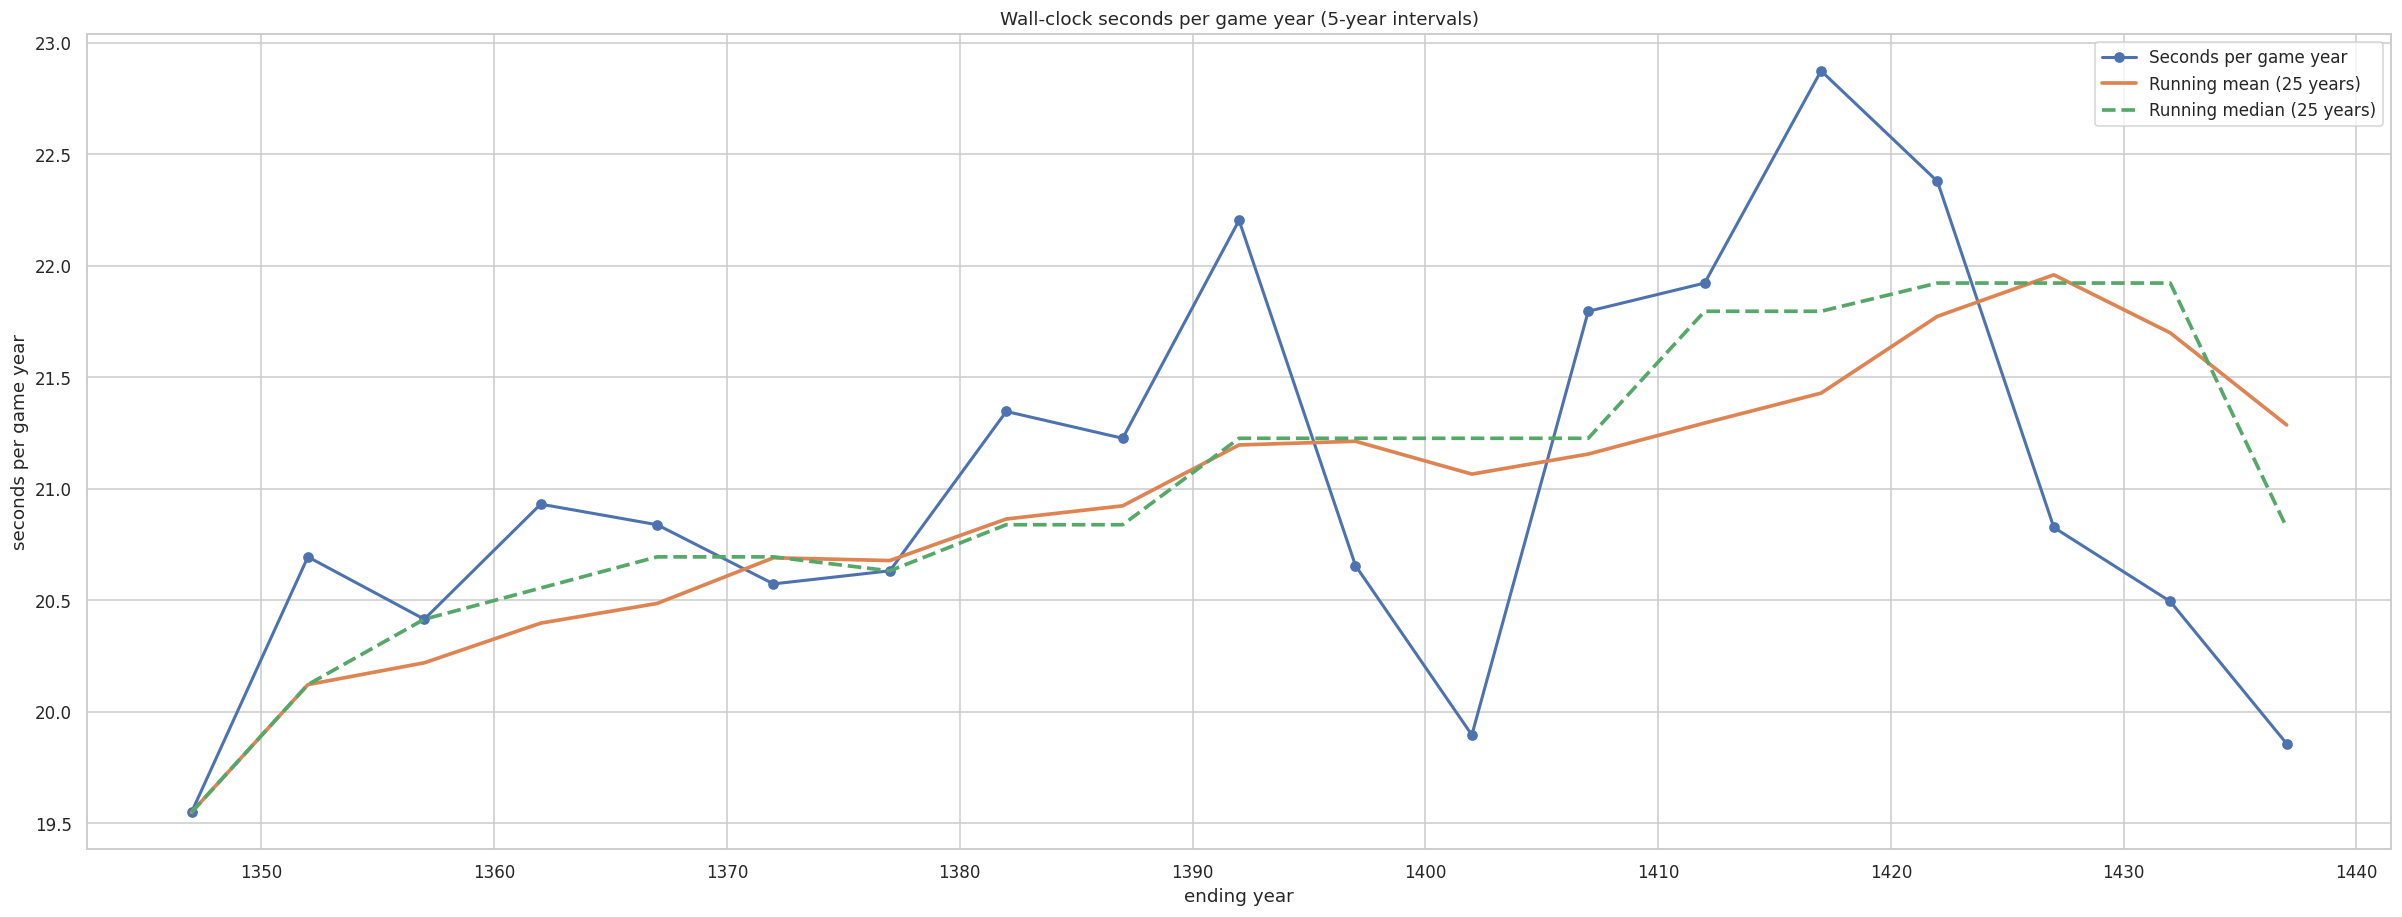

intervals,total_game_years,total_seconds,min_seconds_per_year,mean_seconds_per_year,median_seconds_per_year,max_seconds_per_year,stddev_seconds_per_year
u32,i64,f64,f64,f64,f64,f64,f64
19,95,1995.53,19.55,21.01,20.83,22.87,0.89


In [2]:
# Examples:
# playthrough = None       # None uses the latest playthrough from graphs/dataset
# start_date = None        # example: 13370101
# end_date = None          # example: 14000101
# interval_years = 5       # save resolution is usually 5 game years
# rolling_intervals = 5    # 5 intervals at 5-year resolution = 25-year rolling window
playthrough = None
start_date = None
end_date = None
interval_years = 5
rolling_intervals = 5

runtime_workbench = data.workbench(
    playthrough=playthrough,
    start_date=start_date,
    end_date=end_date,
)
runtime = nb.show_runtime_cadence(
    data,
    runtime_workbench,
    interval_years=interval_years,
    rolling_intervals=rolling_intervals,
)
savegame_cadence_plot = runtime.plot_frame
savegame_cadence_stats = runtime.stats


## Search And Snapshot Context

In [3]:
# Main selection used by the cells below.
# Examples:
# playthrough = None
# start_date = 13370101
# end_date = 14370101
# snapshot_date = None
# good_search = "victuals"
# market_search = "london"
# building_search = "cookery"
# pm_drilldown_search = "packing"
# group_by = "super_region"       # area, region, macro_region, super_region, country
# building_scope = "super_region" # region, macro_region, super_region
# top_n = 6
playthrough = None
start_date = None
end_date = None
snapshot_date = None

good_search = "victuals"
market_search = None
building_search = "cookery"
pm_drilldown_search = None
country_search = "england"

group_by = "super_region"
building_scope = "super_region"
flow_group_by = ("flow_table", "market")
consumption_group_by = "bucket"
imbalance_sort = "mean_flow"
agg = "sum"
top_n = 6
bucket_years = 25
start_year = 1337
population_metric = "total_population"
food_rank_by = "food_fill_ratio"
building_metric = "level"

workbench = data.workbench(
    playthrough=playthrough,
    start_date=start_date,
    end_date=end_date,
    snapshot_date=snapshot_date,
    good_search=good_search,
    market_search=market_search,
    building_search=building_search,
    pm_drilldown_search=pm_drilldown_search,
    country_search=country_search,
    group_by=group_by,
    building_scope=building_scope,
    flow_group_by=flow_group_by,
    consumption_group_by=consumption_group_by,
    imbalance_sort=imbalance_sort,
    agg=agg,
    top_n=top_n,
    bucket_years=bucket_years,
    start_year=start_year,
    population_metric=population_metric,
    food_rank_by=food_rank_by,
    building_metric=building_metric,
)
goods_matches, market_matches, building_matches, pm_matches, country_matches, snapshot_summary = nb.show_selection(workbench)


repo: /home/jan/development/ProsperOrPerishConstructor
data: /home/jan/development/ProsperOrPerishConstructor/graphs/dataset
data mode: raw
playthrough: c49801fe_ebdb_4b42_8b4a_7f1b1715b956
good: Victuals (victuals)
market search: all markets
building search: cookery
pm drilldown search: none


good_code,good_id,goods_category,good_label
u32,str,str,str
70,"""victuals""","""produced""","""Victuals"""


market_code,market_id,market_center_slug,center_location_id,market_label
u32,i64,str,i64,str
0,0,"""lubeck""",846,"""Lübeck"""
1,1,"""riga""",3662,"""Riga"""
2,2,"""venice""",3291,"""Venice"""
3,3,"""novgorod""",5272,"""Novgorod"""
4,4,"""genoa""",3094,"""Genoa"""
5,5,"""london""",1550,"""London"""


building_type_code,building_type,building_label
u32,str,str
48,"""cookery""","""Cookery"""


production_method_code,production_method,production_method_building,production_method_group,production_method_group_index,slot_label,production_method_label
u32,str,str,str,i64,str,str
0,"""ablaq_palace_maintenance""",null,null,null,"""Unslotted""","""Ablaq Palace"""
1,"""alum_dyes_guild_maintenance""","""dyes_guild""","""dyes_guild:unique_production_m…",0,"""Slot 1""","""Alum-Fixed Dyes"""
2,"""alum_fine_cloth_guild_maintena…","""fine_cloth_guild""","""fine_cloth_guild:unique_produc…",1,"""Enhancements:""","""Dyes with Alum"""
3,"""amber_enhancement""","""jewelry_guild""","""jewelry_guild:unique_productio…",1,"""Enhancements:""","""Amber Enhancements"""
4,"""ancient_medicine_apotechary""","""apothecary""","""apothecary:unique_production_m…",0,"""Slot 1""","""Ancient Medicines"""
5,"""aqueduct_system_maintenance""",null,null,null,"""Unslotted""","""Aqueduct Systems"""


country_code,country_tag,country_label
u32,str,str
385,"""ENG""","""England"""


playthrough_id,snapshots,first_year,last_year
str,u32,u16,u16
"""SP_Observer_1437_12_11_c49801f…",1,1437,1437
"""c49801fe_ebdb_4b42_8b4a_7f1b17…",21,1342,1437


## Global Composition Over Time

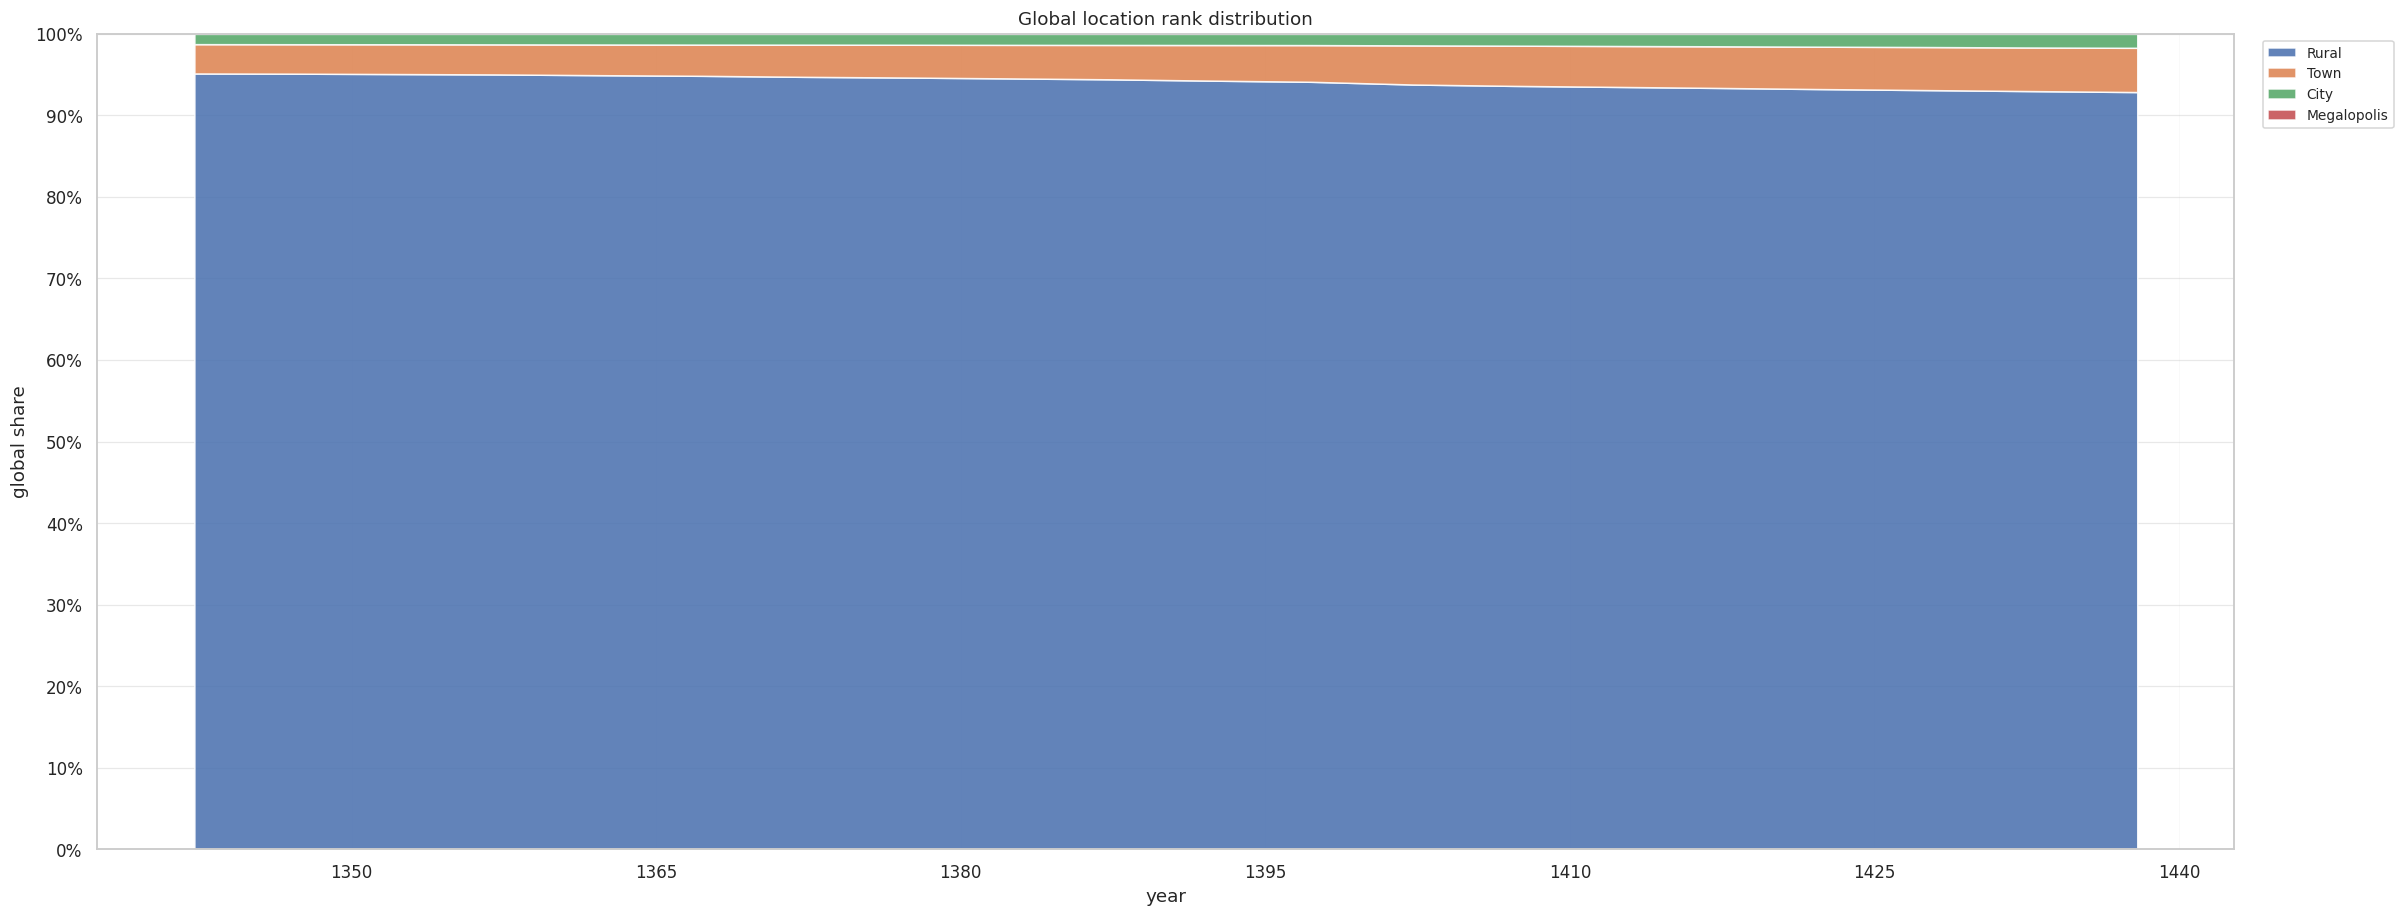

In [4]:
# Uses playthrough/start/end from the main selection cell.
location_rank = nb.show_location_rank_distribution(data, workbench)
location_rank_distribution = location_rank.frame


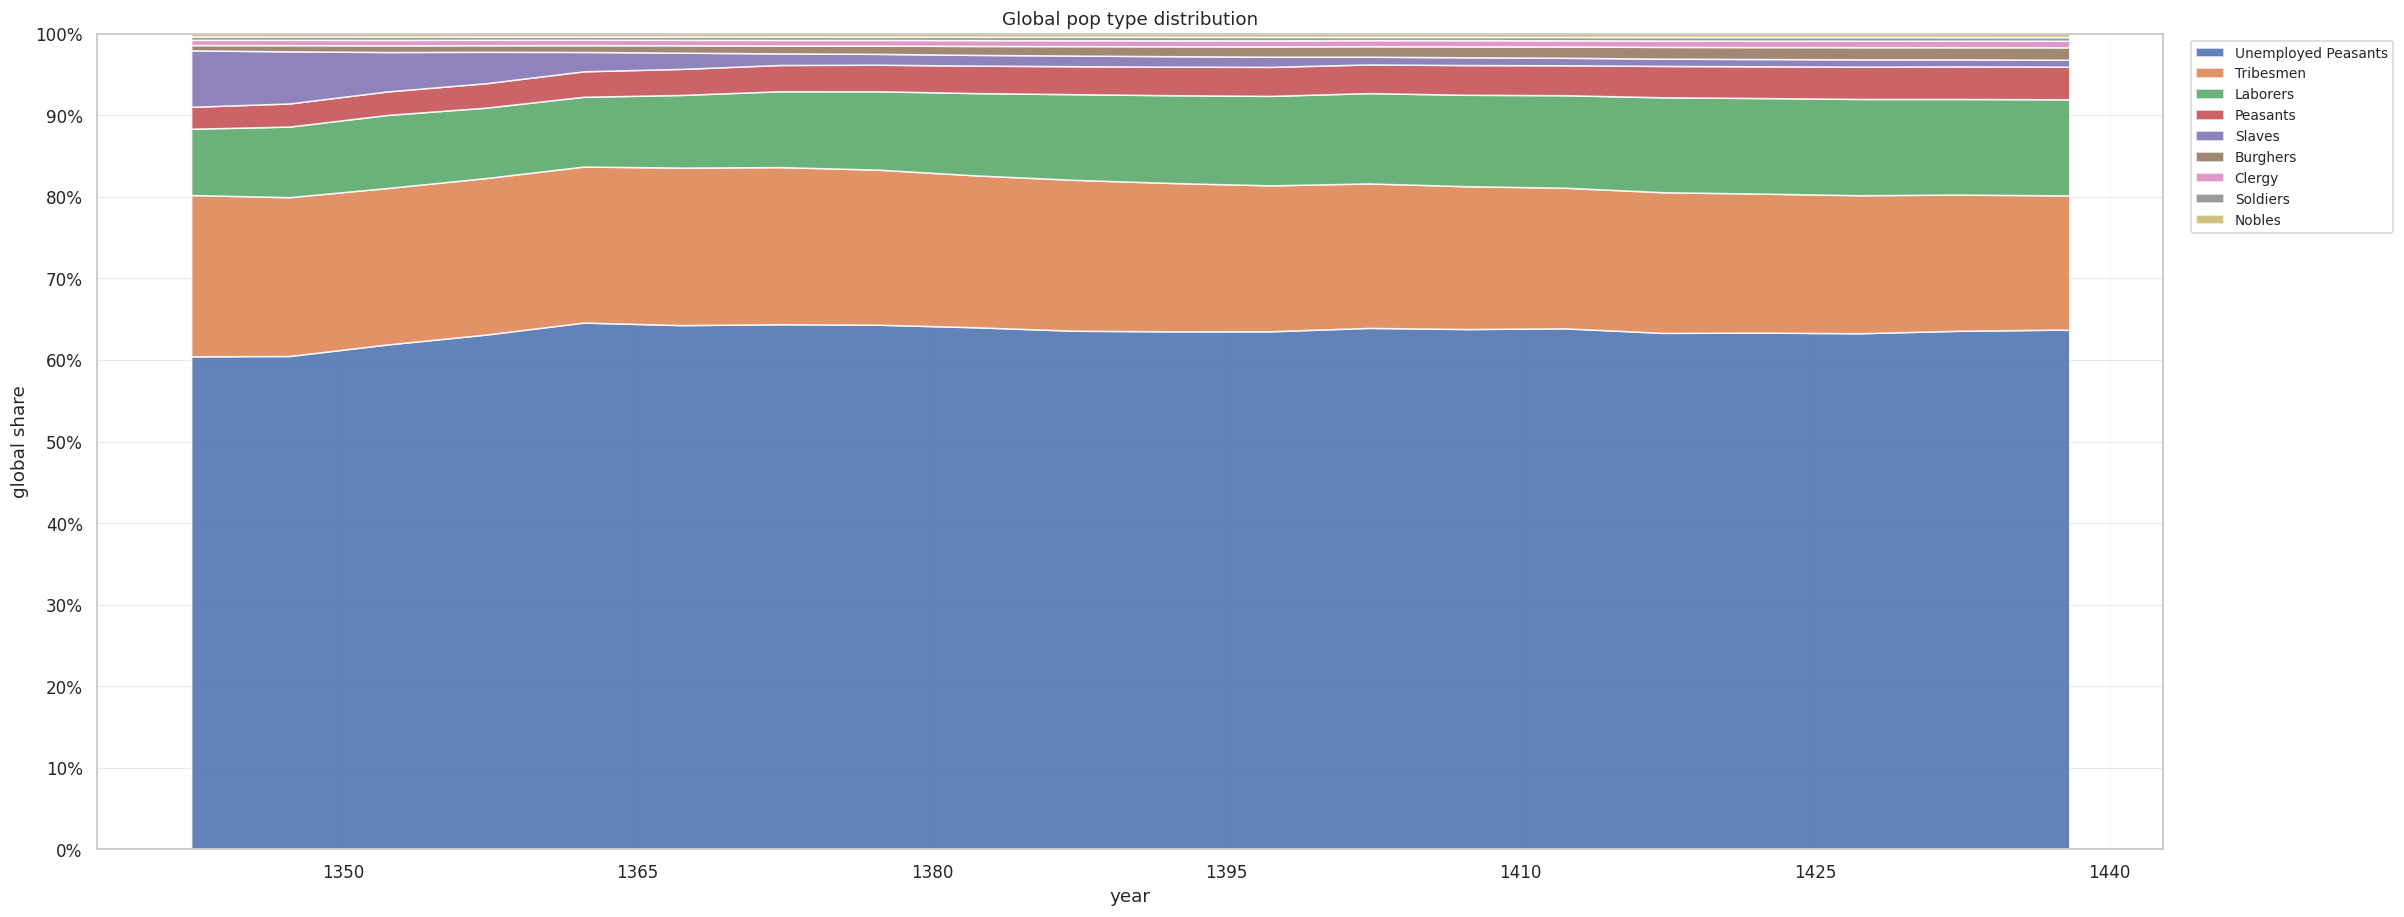

In [5]:
# Uses playthrough/start/end from the main selection cell.
pop_types = nb.show_pop_type_distribution(data, workbench)
pop_type_distribution = pop_types.frame


## Population / Locations Over Time

In [6]:
# Uses population_metric/group_by/agg/top_n from the main selection cell.
population = workbench.population()
population_latest = population.latest
population_delta = population.delta
population_ts = population.time_series
population_ts_top = population.top_time_series
population_global = population.global_time_series


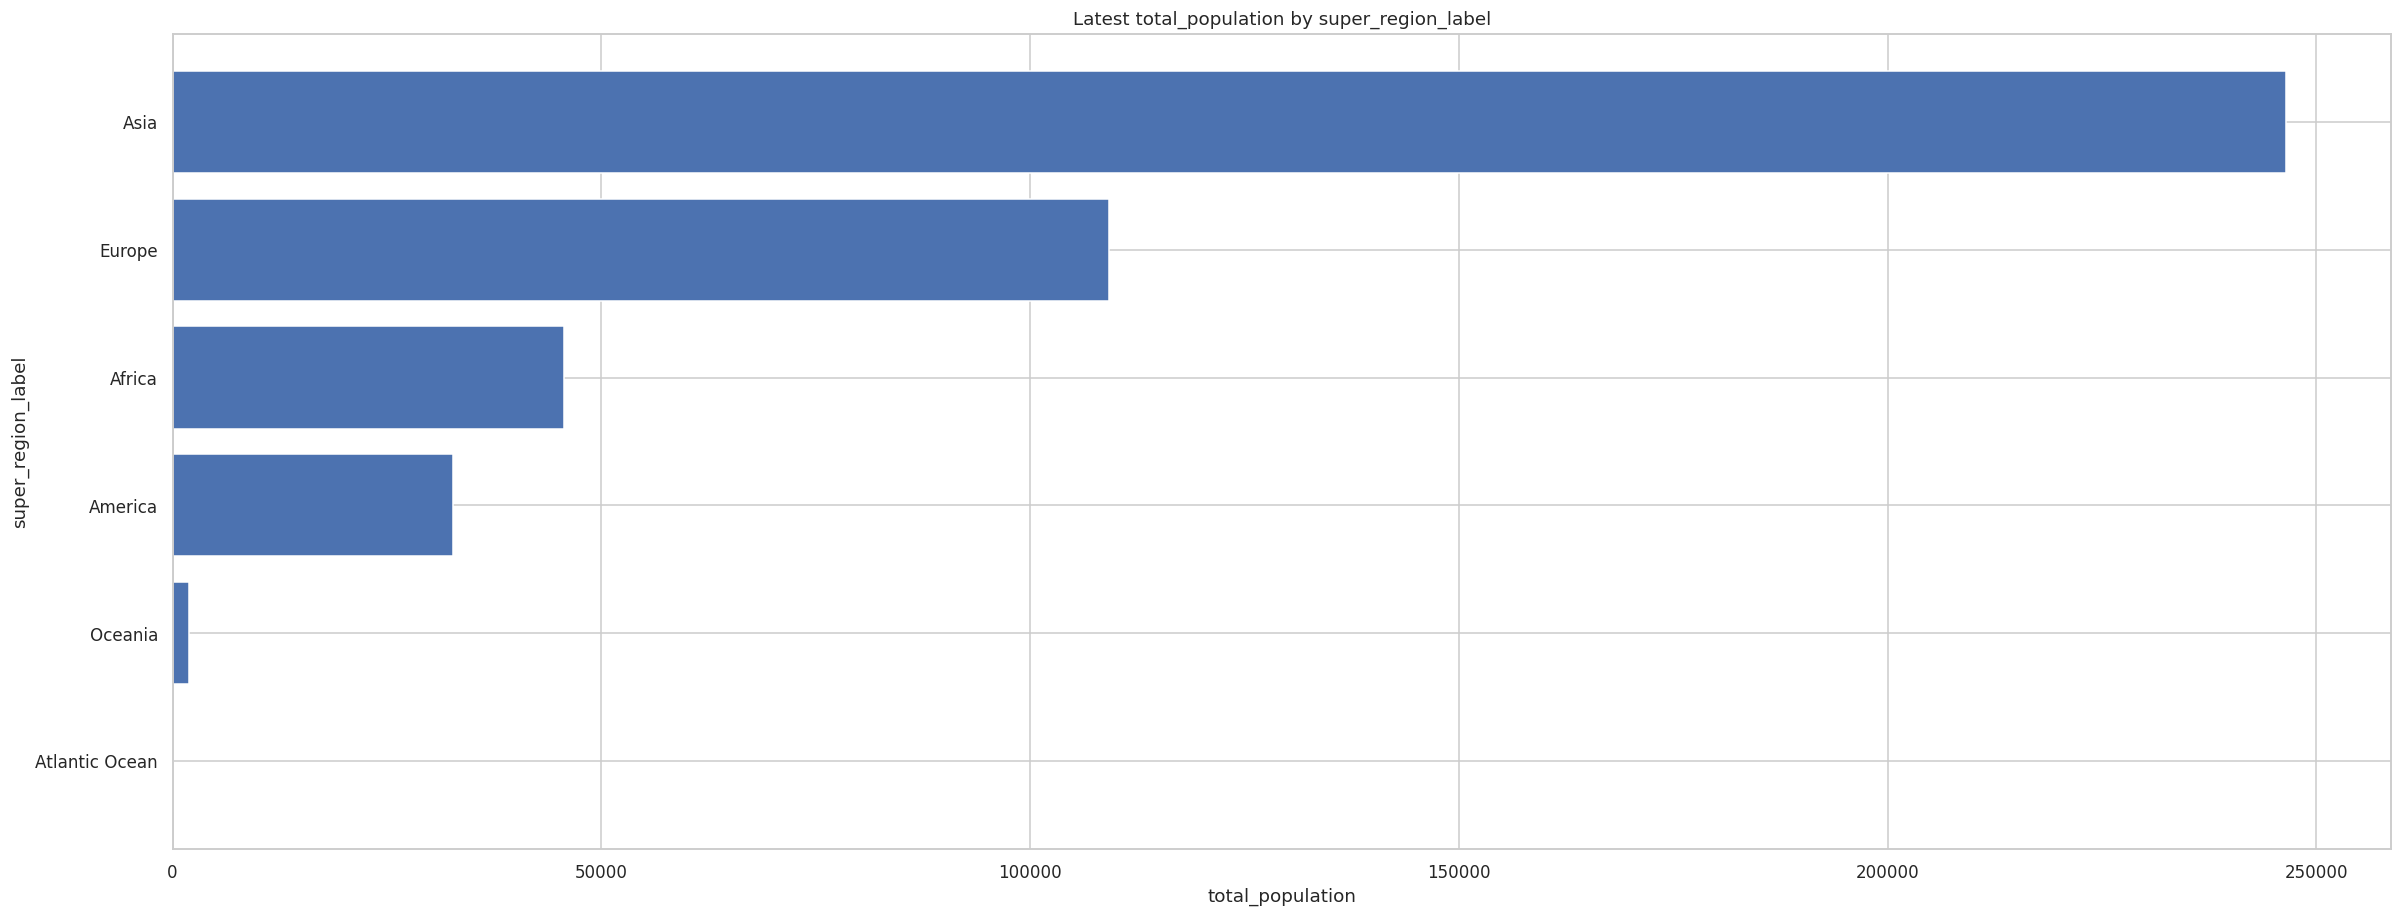

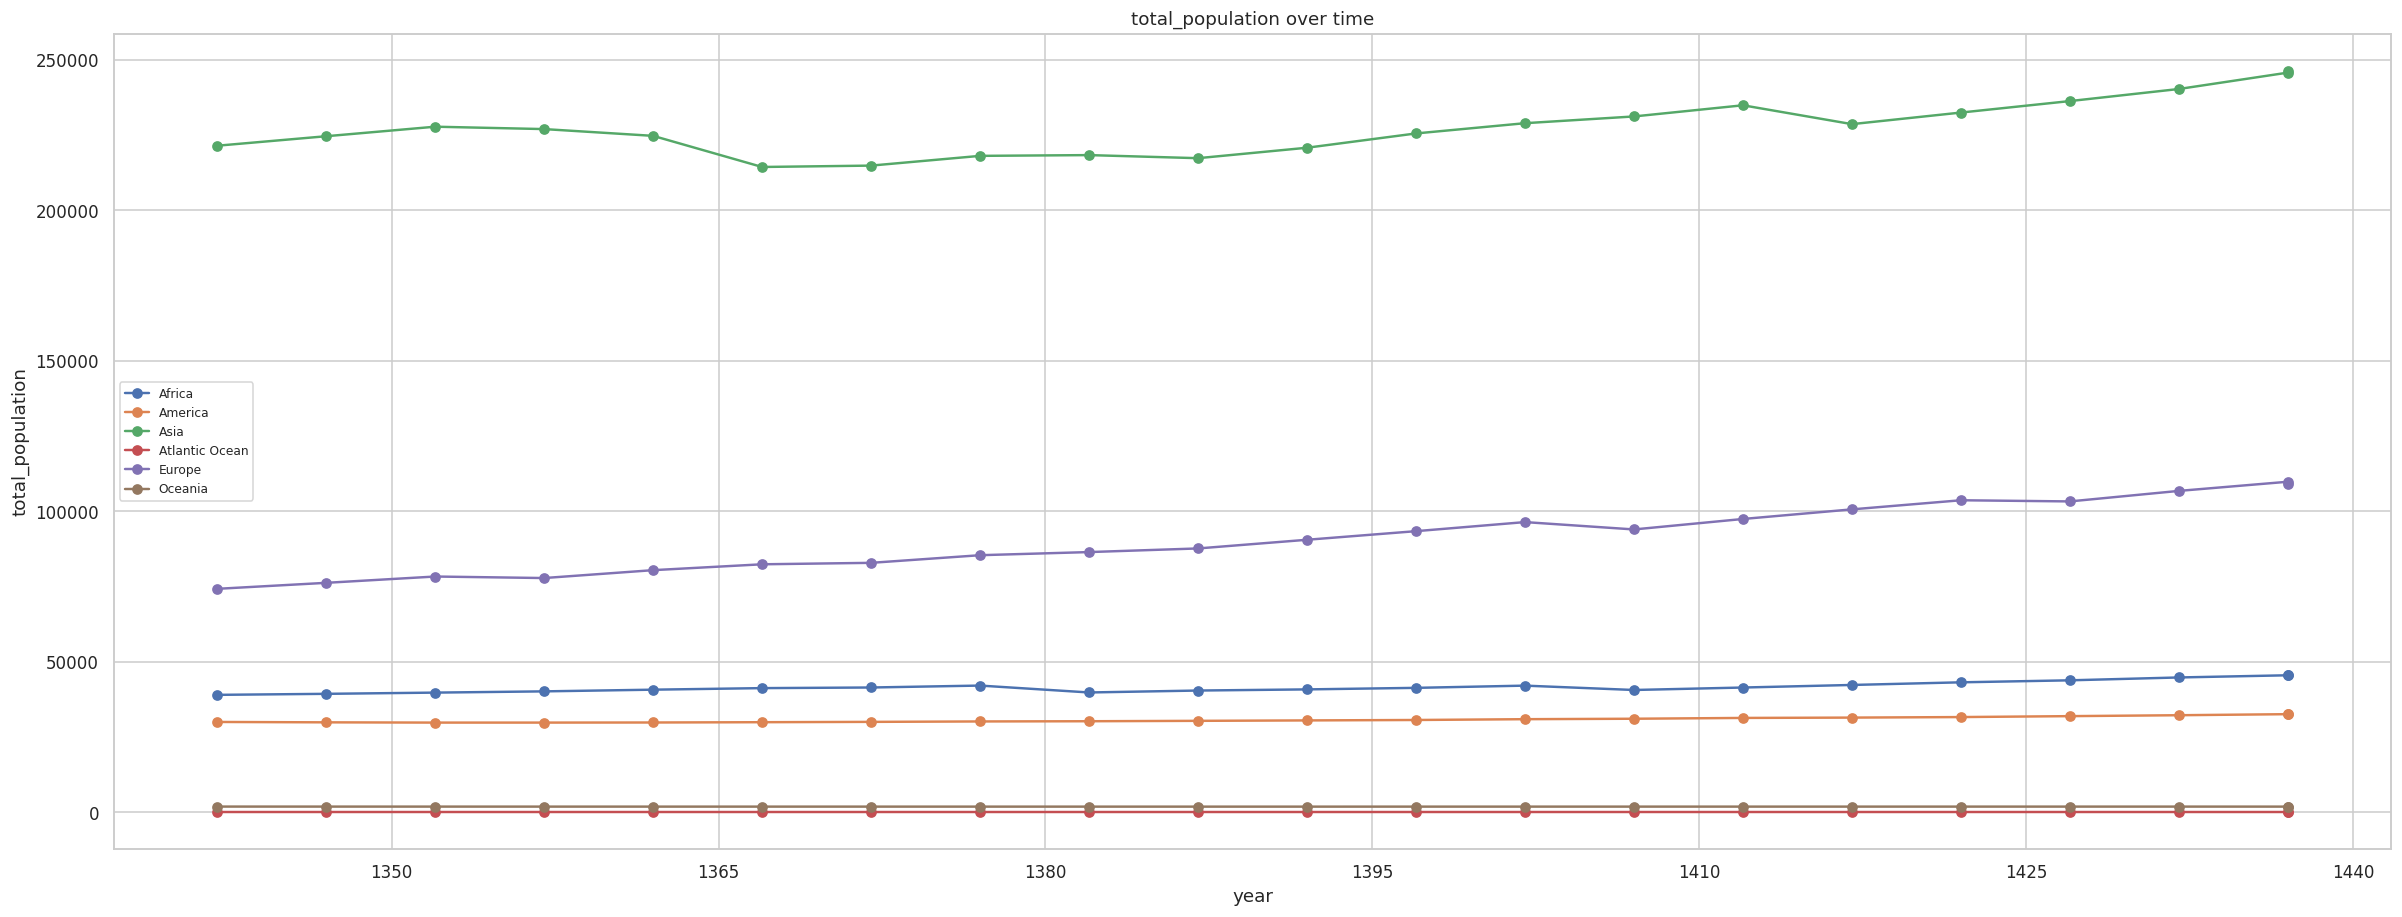

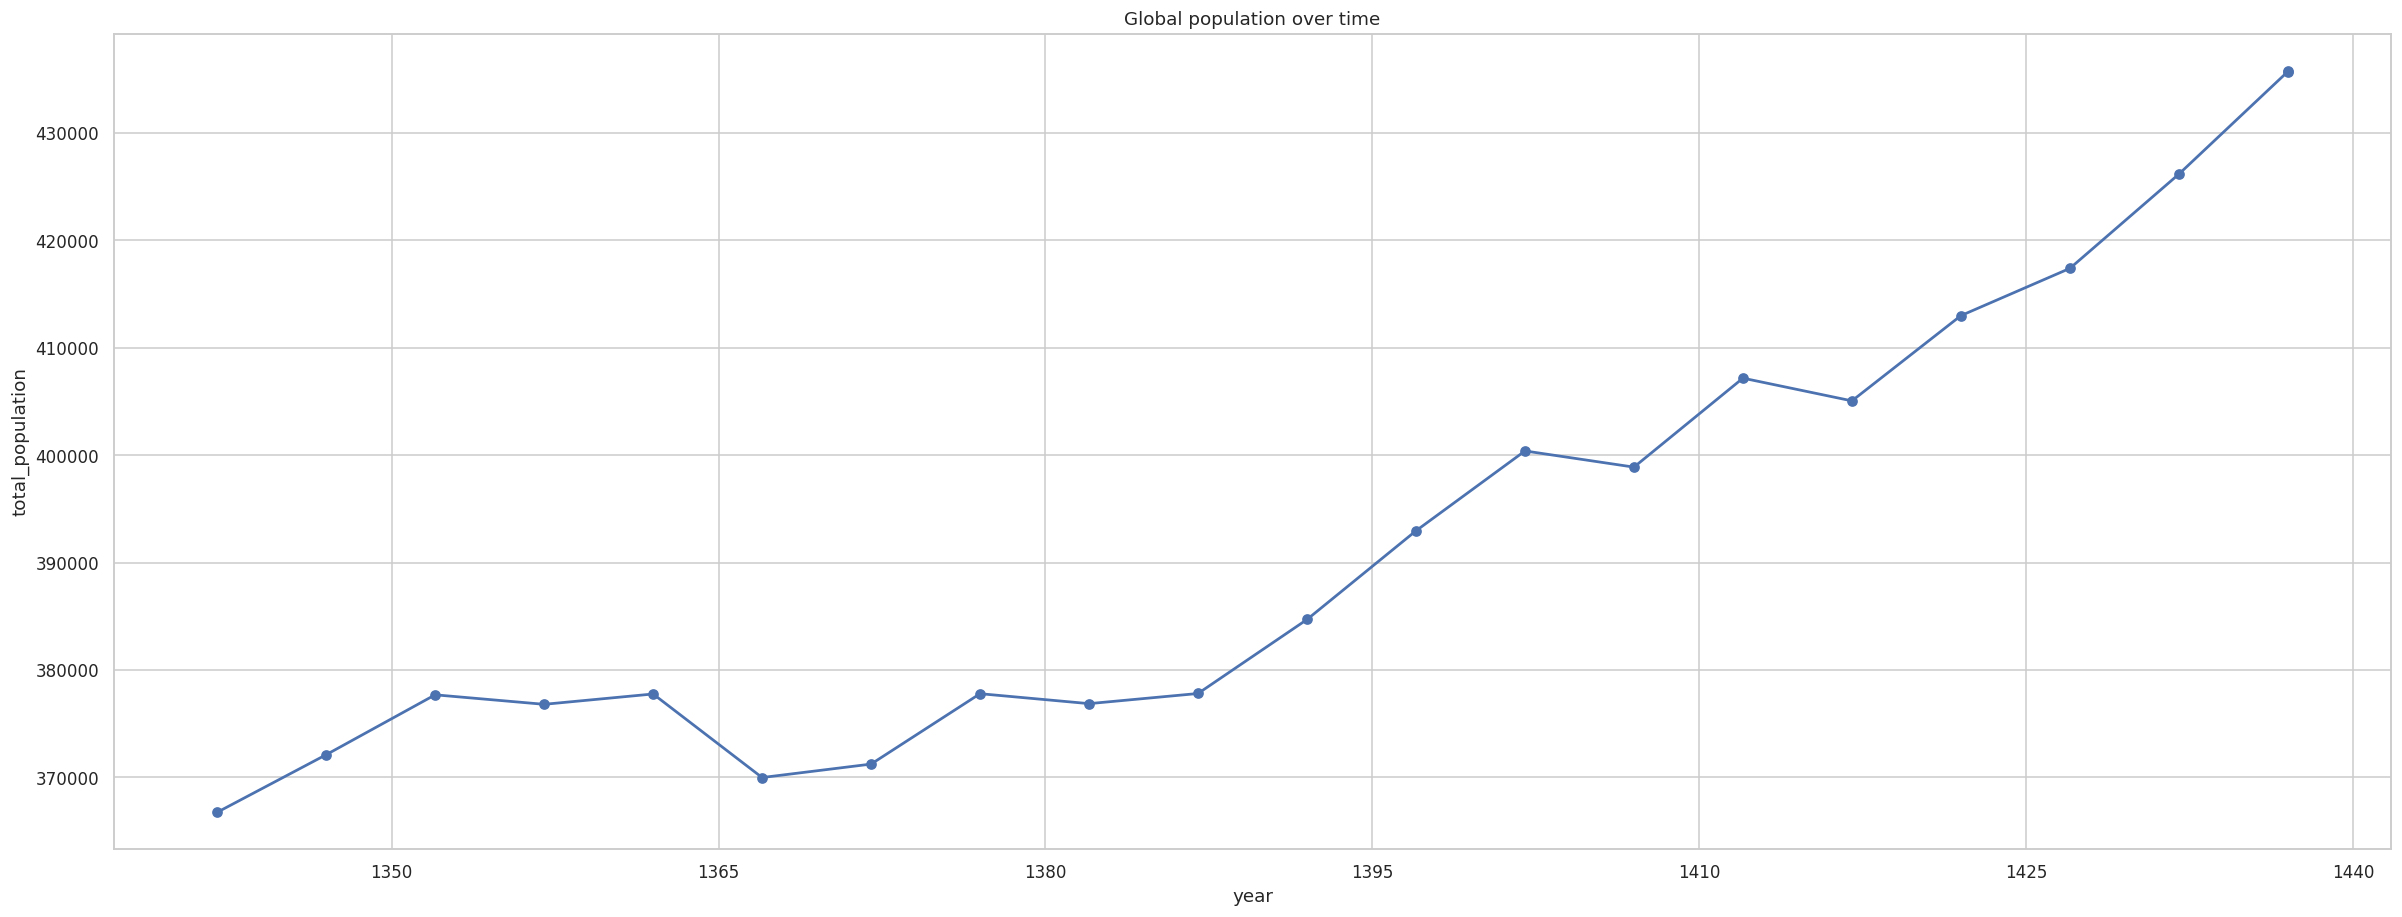

In [7]:
workbench.plot_population(population)


## Global Buildings Over Time

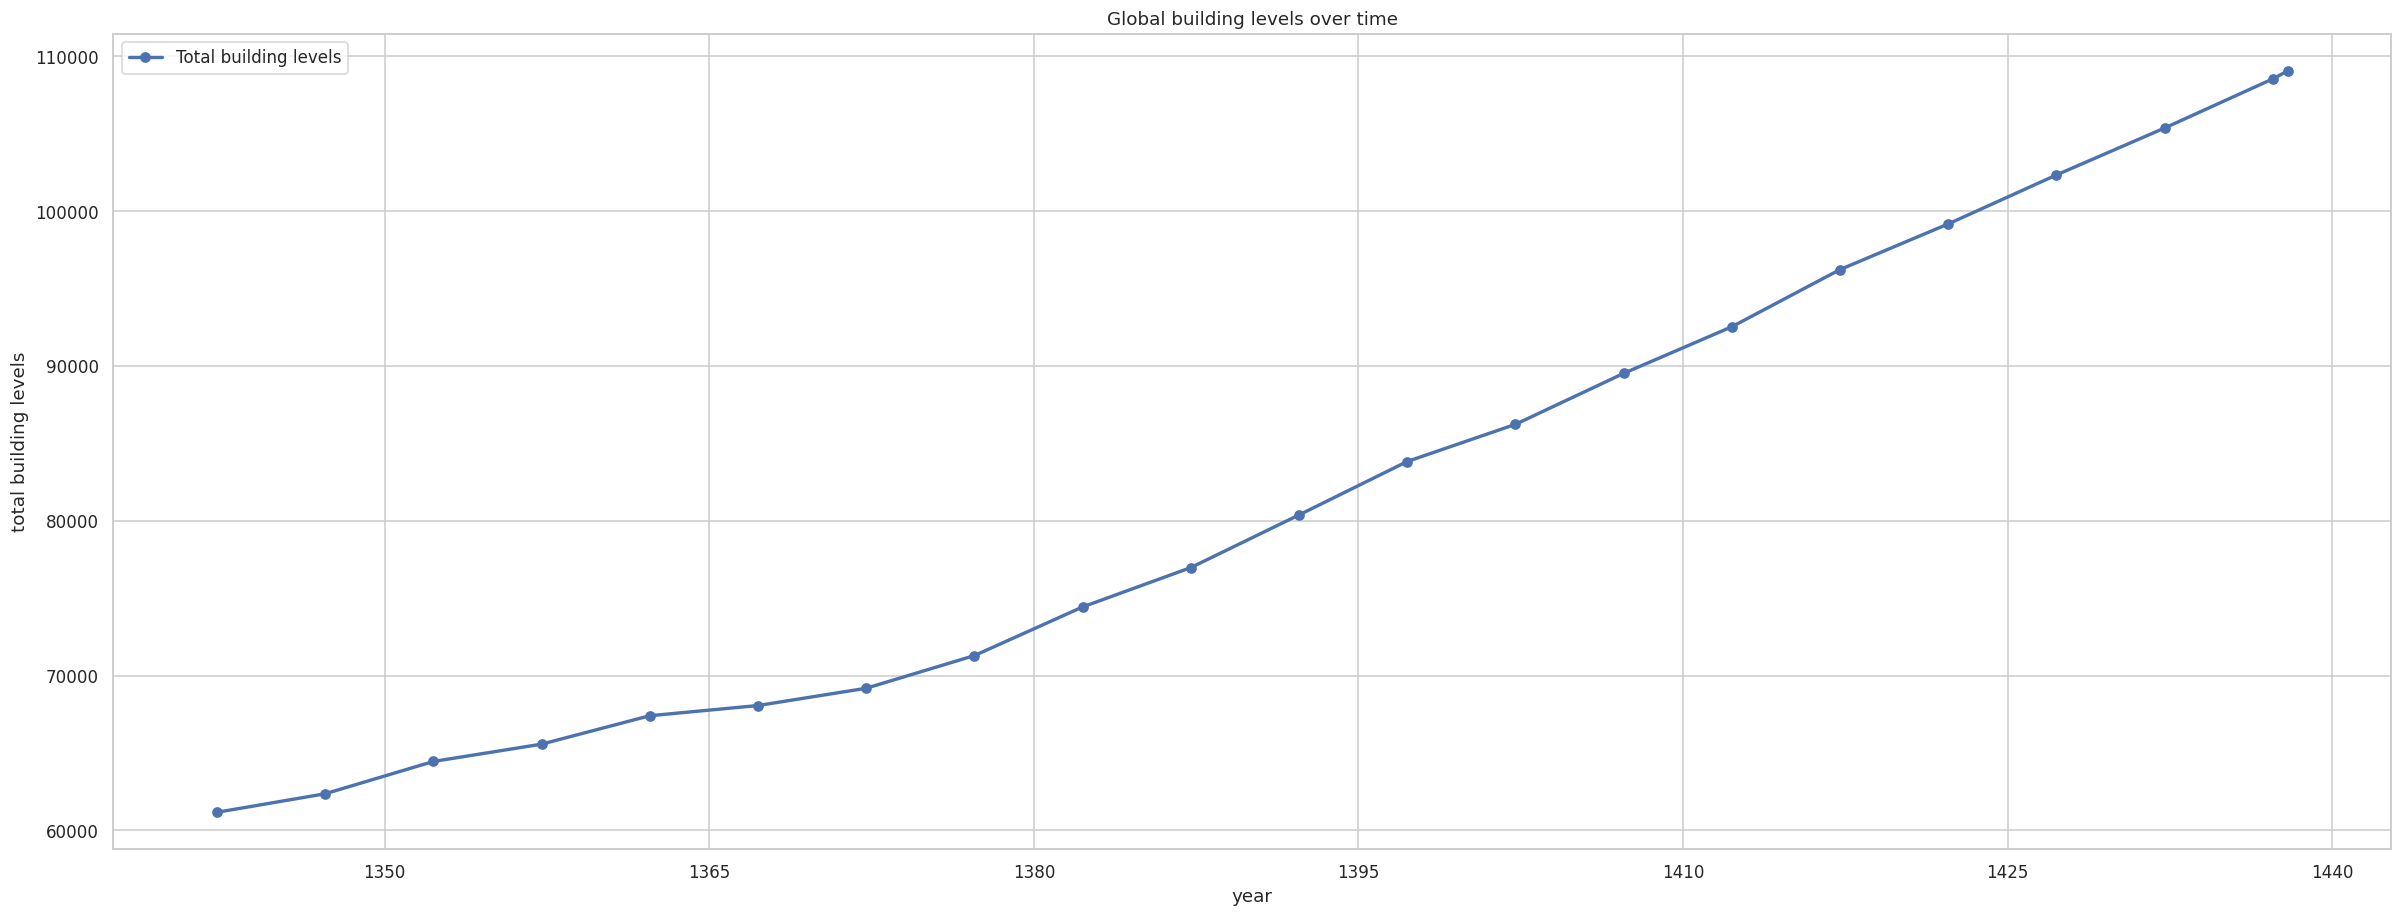

In [8]:
# Uses playthrough/start/end from the main selection cell.
global_buildings = nb.show_global_buildings(data, workbench)
global_buildings_ts = global_buildings.time_series


## Infrastructure Buildings Over Time


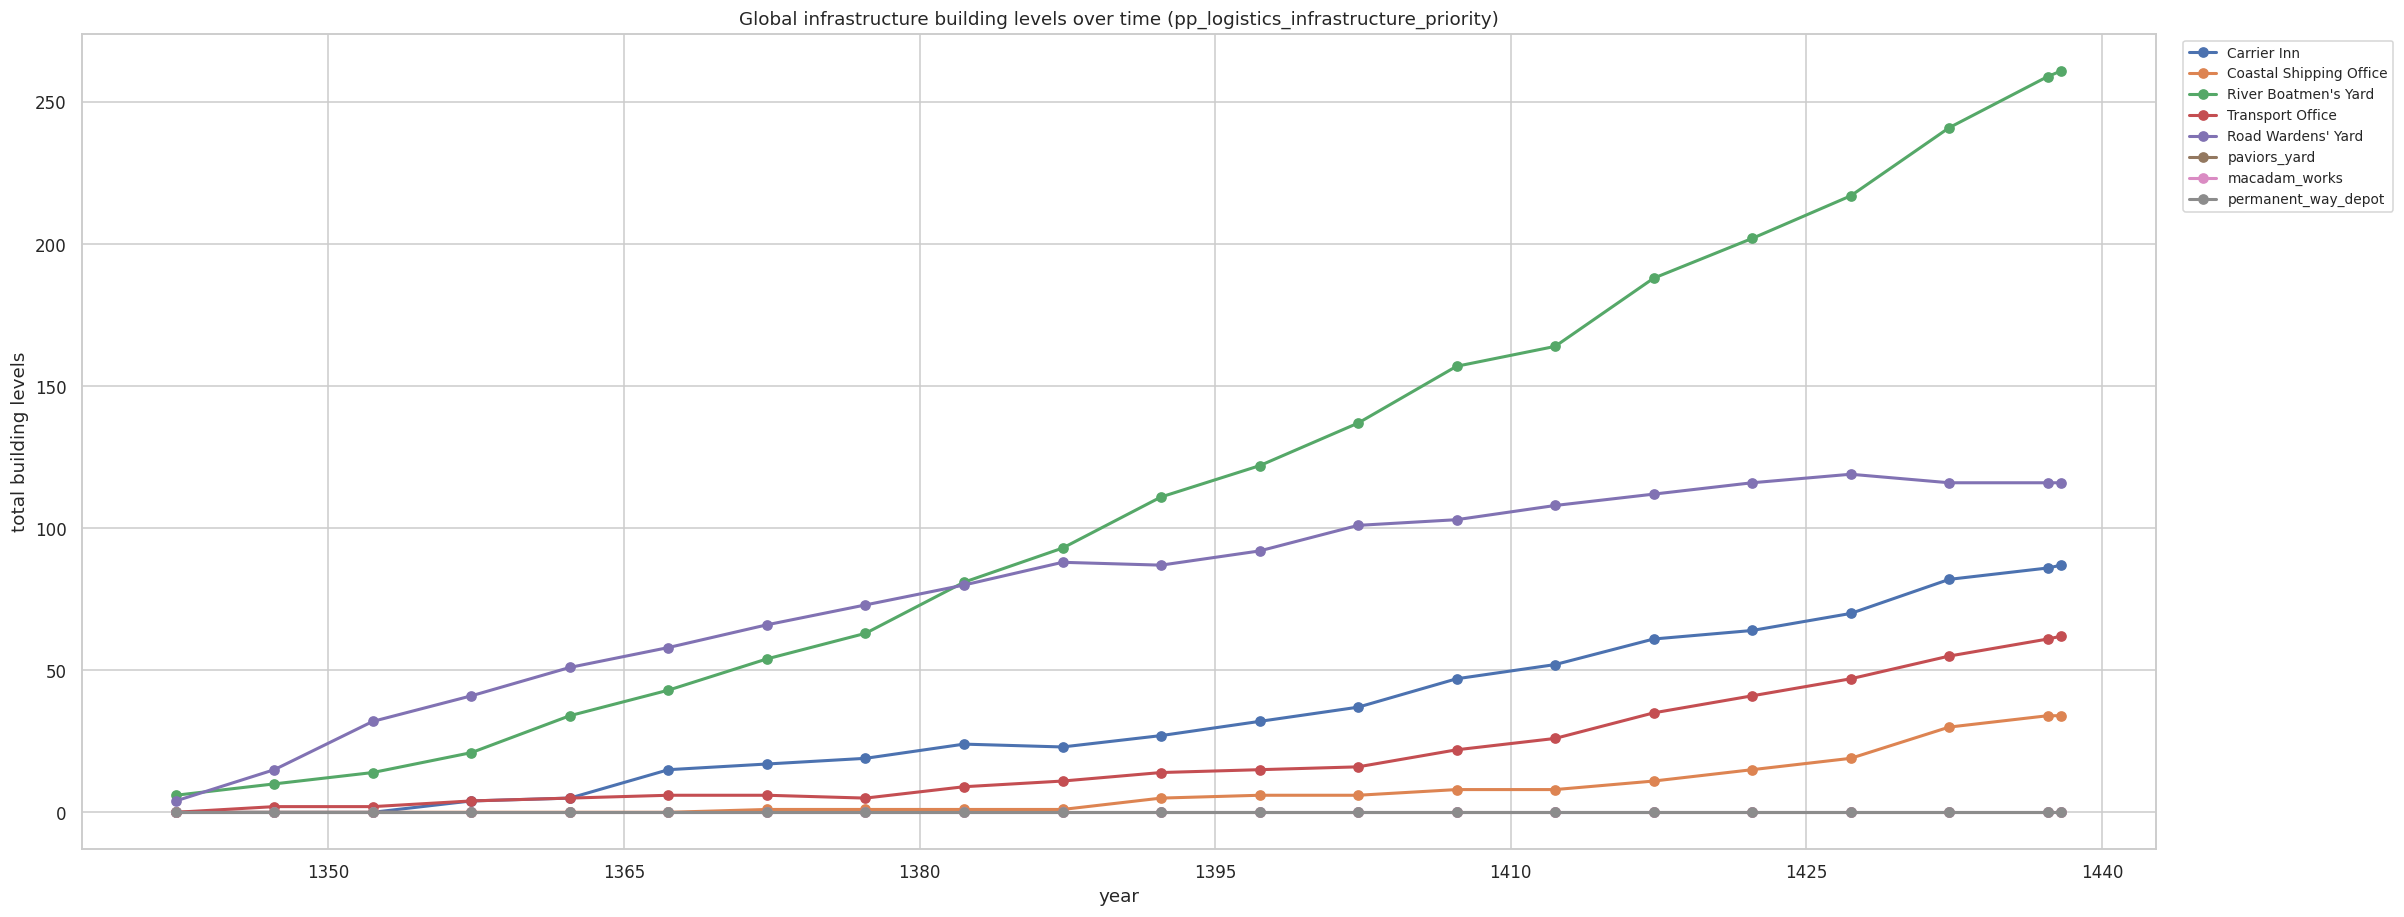

building_type,building_label,total_building_levels,building_records
str,str,f64,i64
"""carrier_inn""","""Carrier Inn""",87.0,82
"""coastal_shipping_office""","""Coastal Shipping Office""",34.0,19
"""river_boatmen_yard""","""River Boatmen's Yard""",261.0,183
"""transport_office""","""Transport Office""",62.0,35
"""road_wardens_yard""","""Road Wardens' Yard""",116.0,118
"""paviors_yard""","""paviors_yard""",0.0,0
"""macadam_works""","""macadam_works""",0.0,0
"""permanent_way_depot""","""permanent_way_depot""",0.0,0


In [9]:
# Examples:
# infrastructure_tag = "pp_logistics_infrastructure_priority"
# fallback_order = nb.INFRASTRUCTURE_BUILDING_ORDER
infrastructure_tag = "pp_logistics_infrastructure_priority"
fallback_order = nb.INFRASTRUCTURE_BUILDING_ORDER

infrastructure = nb.show_infrastructure_buildings(
    data,
    workbench,
    tag=infrastructure_tag,
    fallback_order=fallback_order,
)
infrastructure_buildings = infrastructure.buildings
infrastructure_buildings_ts = infrastructure.time_series
infrastructure_building_latest = infrastructure.latest
infrastructure_building_types = infrastructure.building_types


## Goods And Markets

In [10]:
# Uses good_search/imbalance_sort/bucket_years/start_year from the main selection cell.
goods = workbench.goods()
goods_global_ts = goods.global_time_series
market_scarcity = goods.scarcity
goods_imbalance = goods.imbalance
goods_imbalance_all = goods.goods_imbalance_all
market_flow_value = goods.flow_value


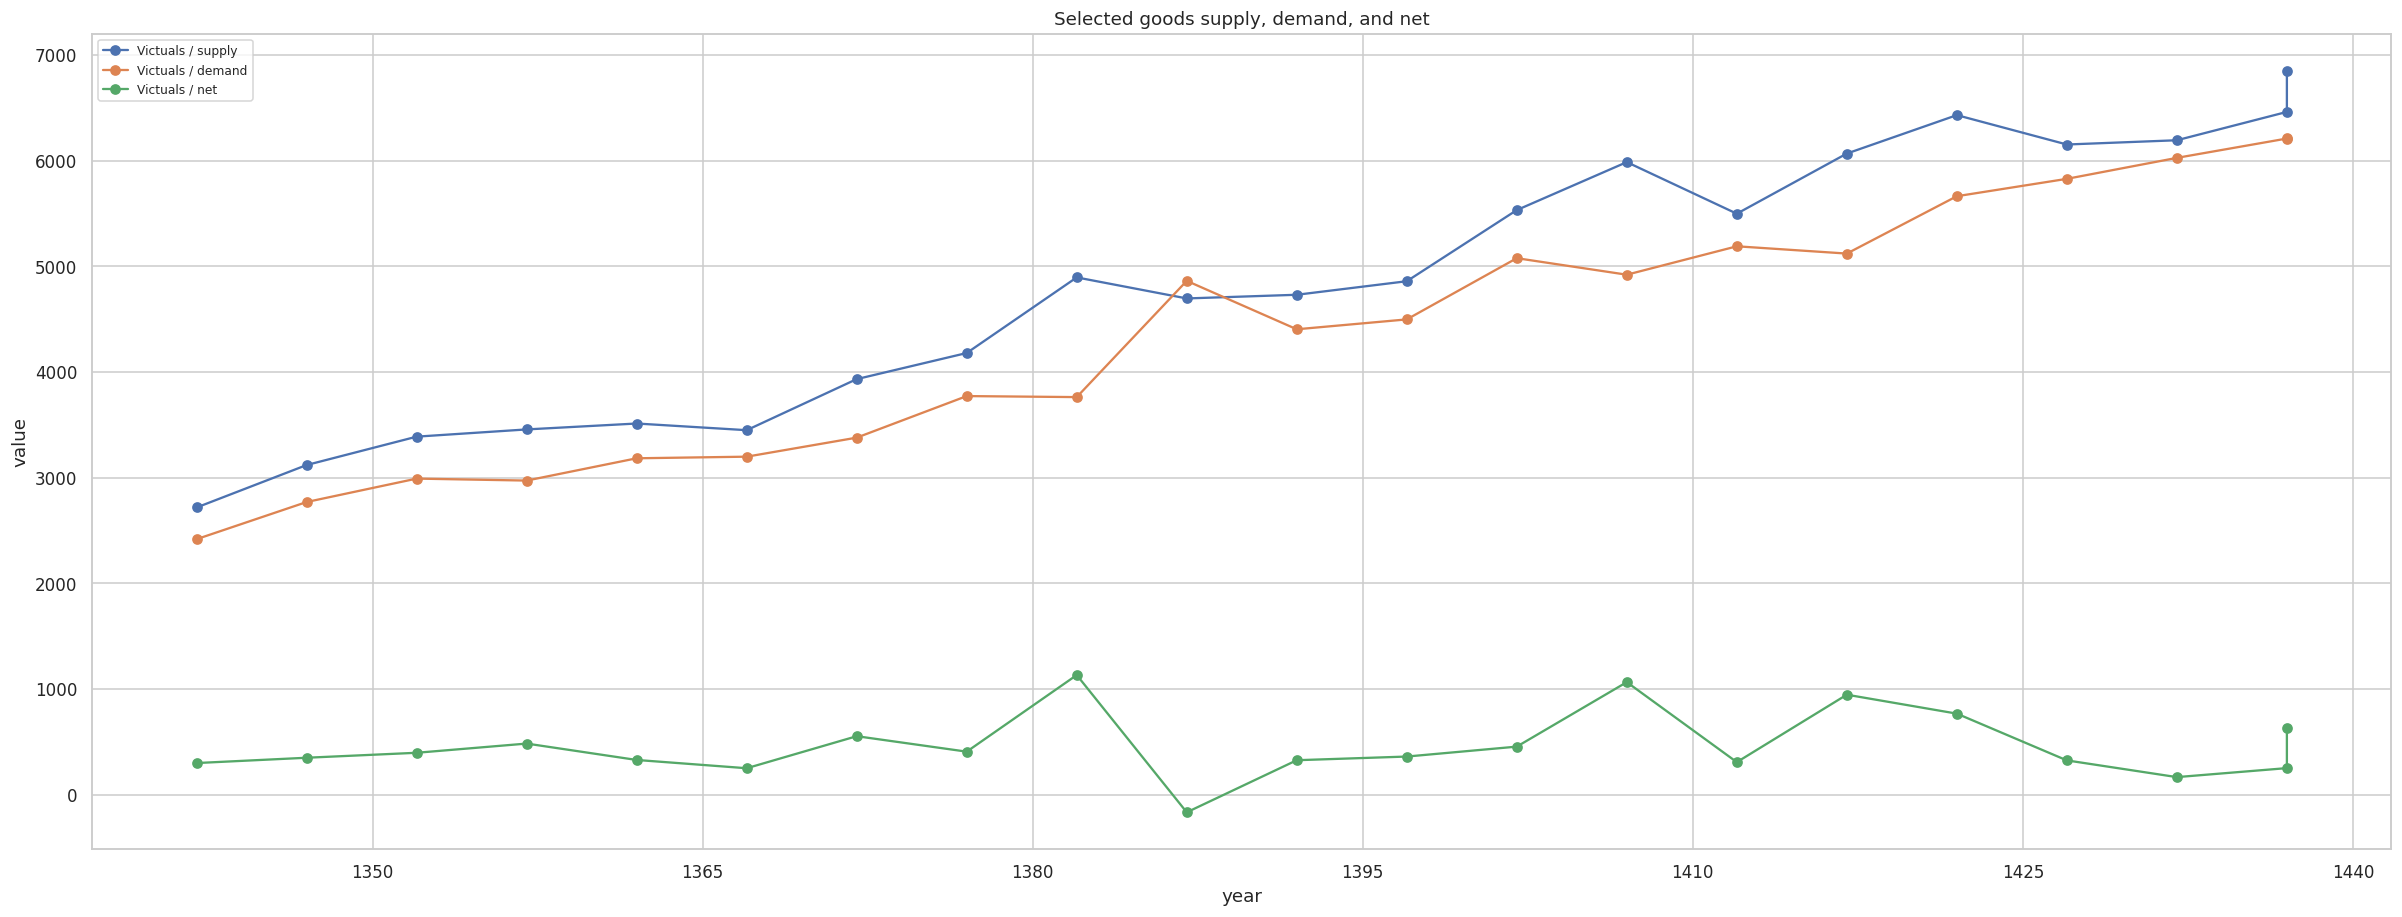

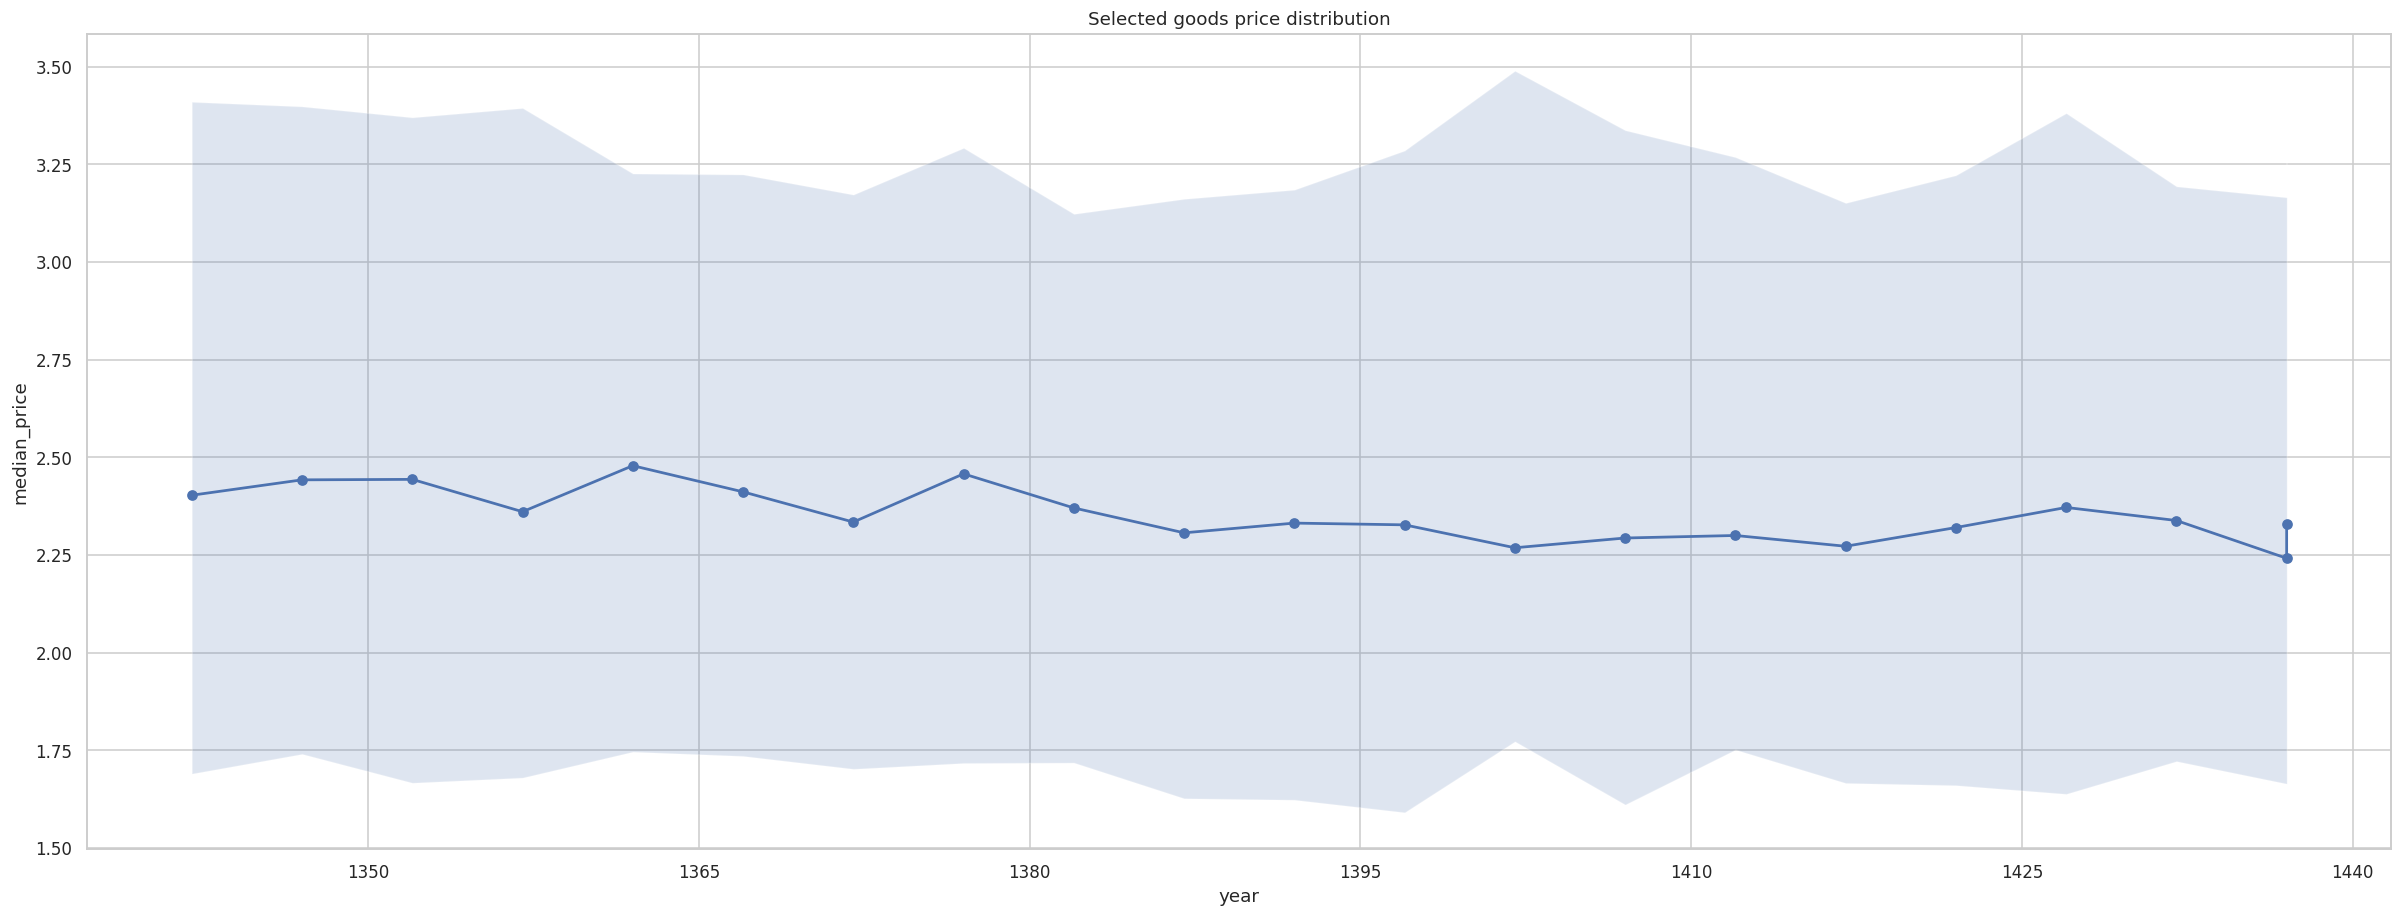

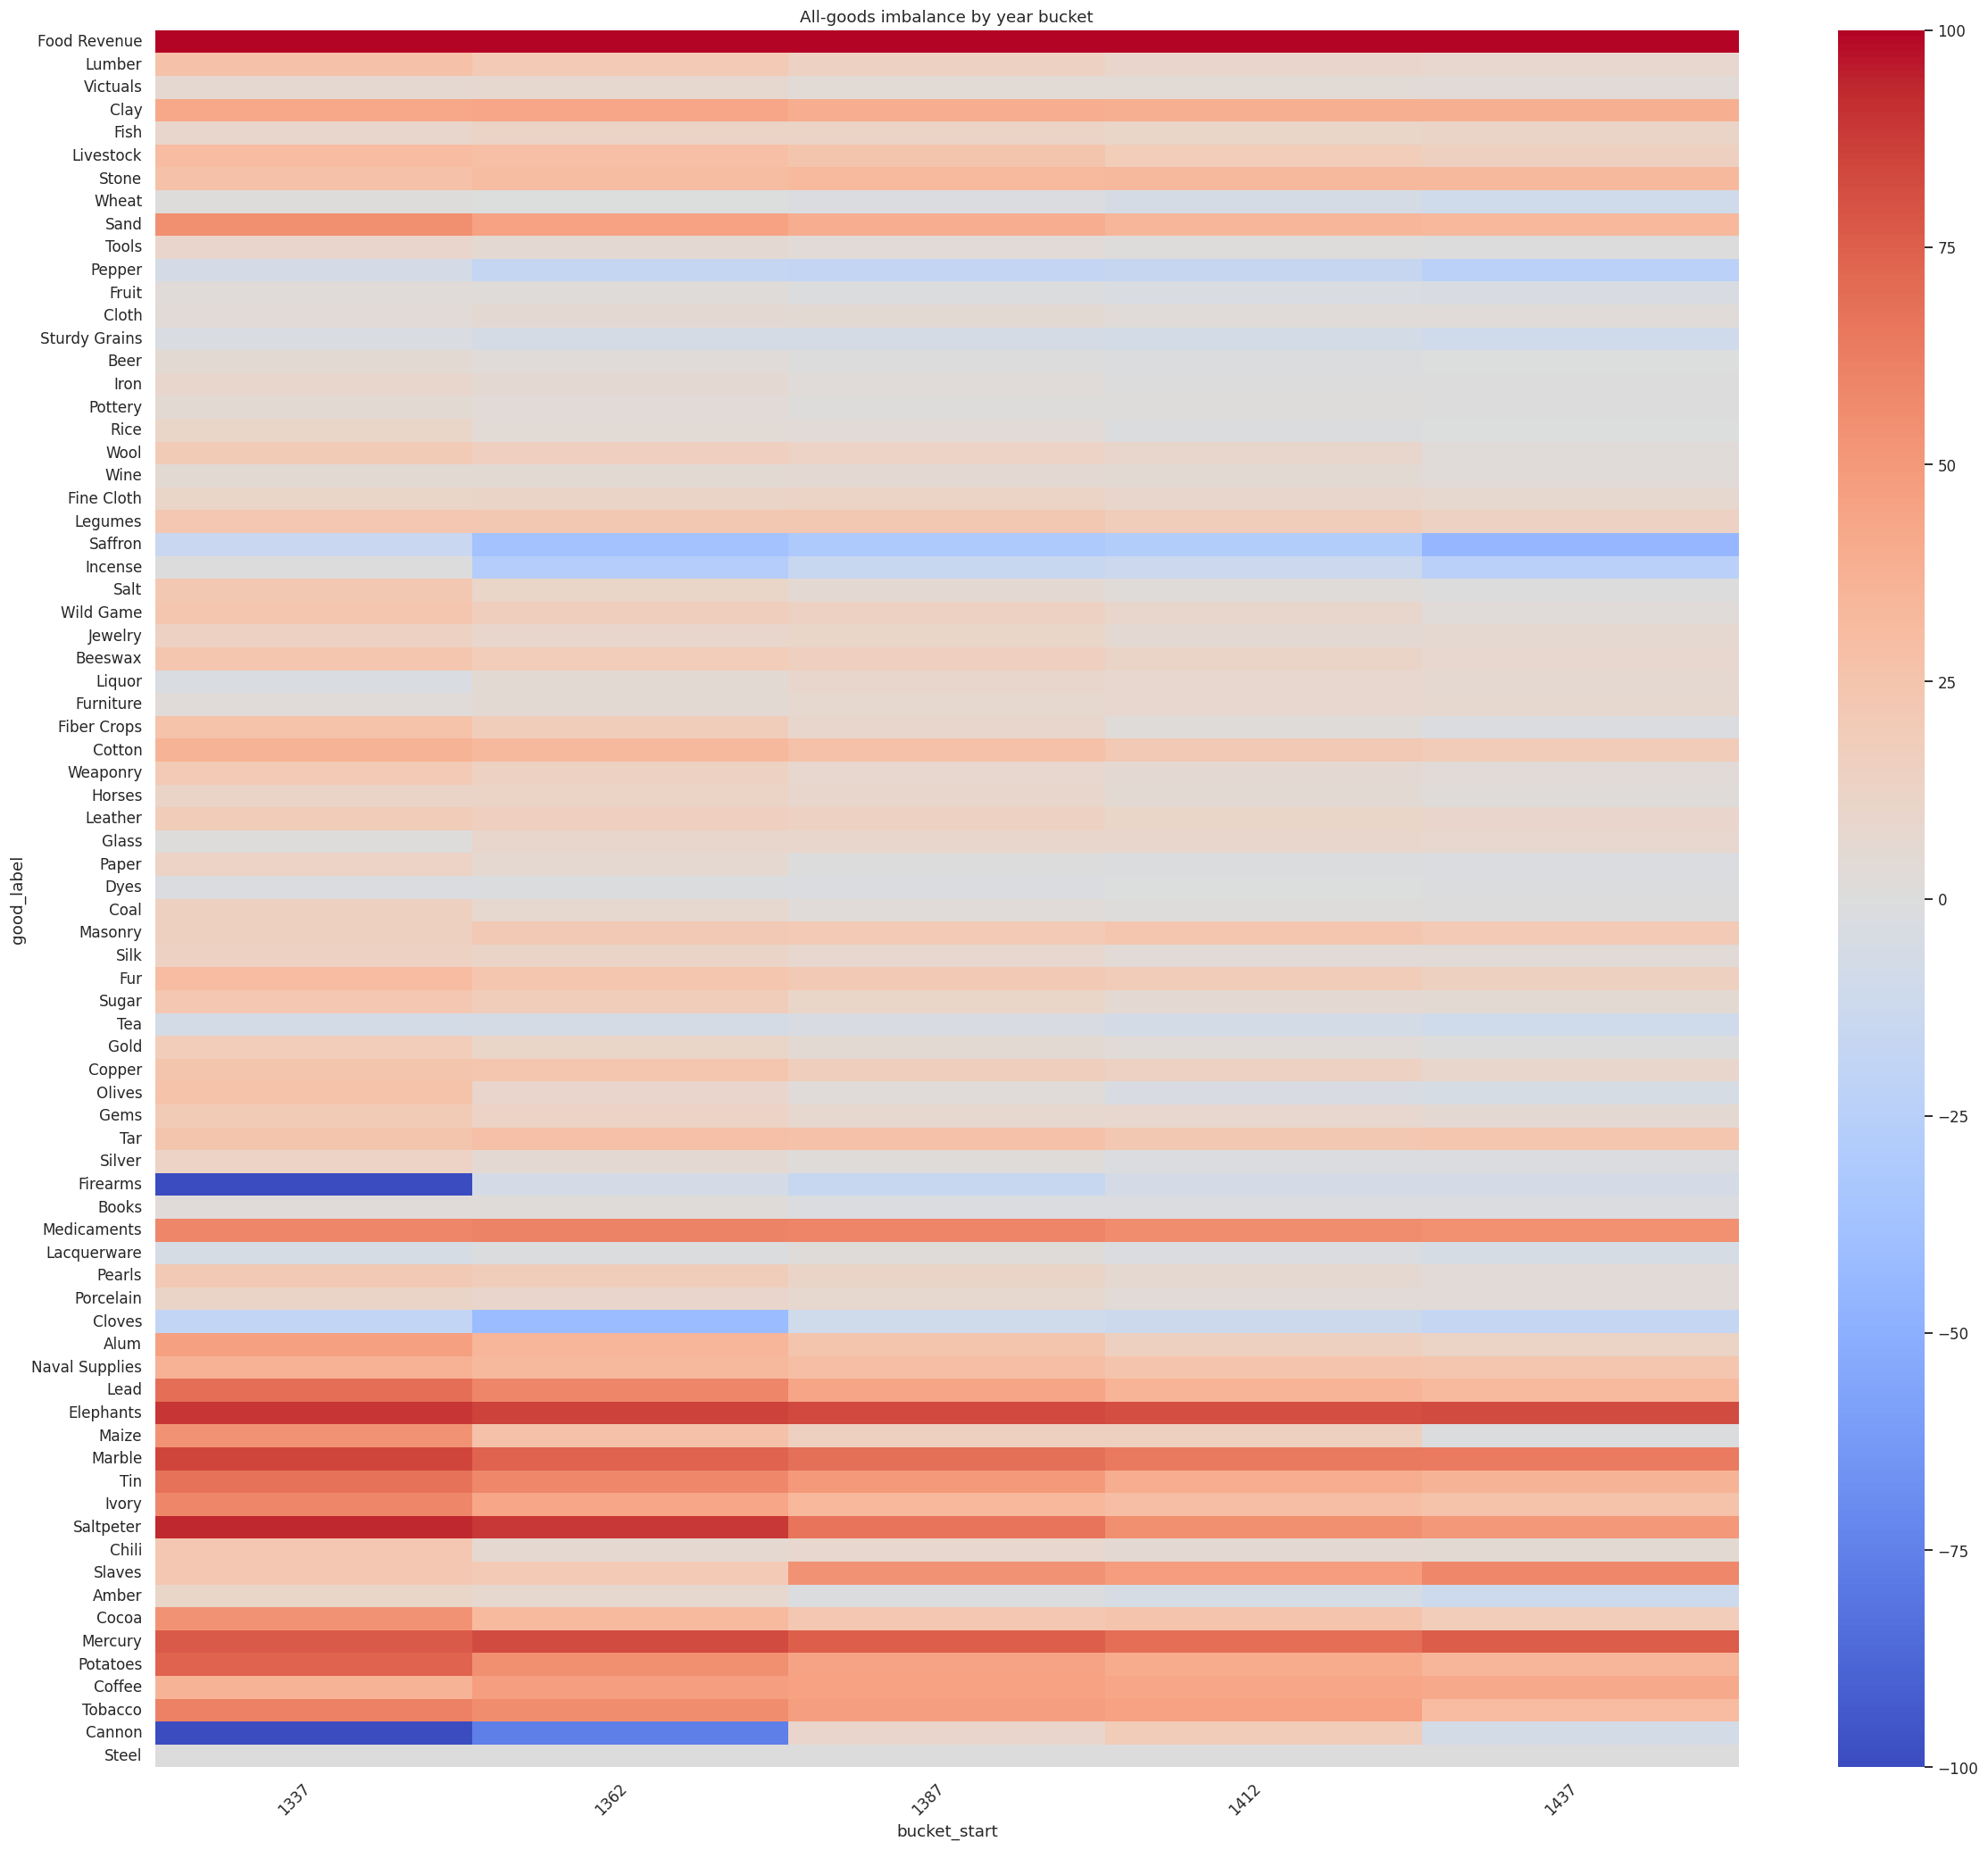

In [11]:
workbench.plot_goods(goods)


## Goods Source / Sink Flows

In [12]:
# Uses good_search/market_search/flow_group_by/consumption_group_by from the main selection cell.
flows = workbench.flows()
source_breakdown = flows.source_breakdown
sink_breakdown = flows.sink_breakdown
source_ts = flows.source_time_series
sink_ts = flows.sink_time_series
good_consumption_latest = flows.good_consumption_latest
good_consumption_over_time = flows.good_consumption_over_time


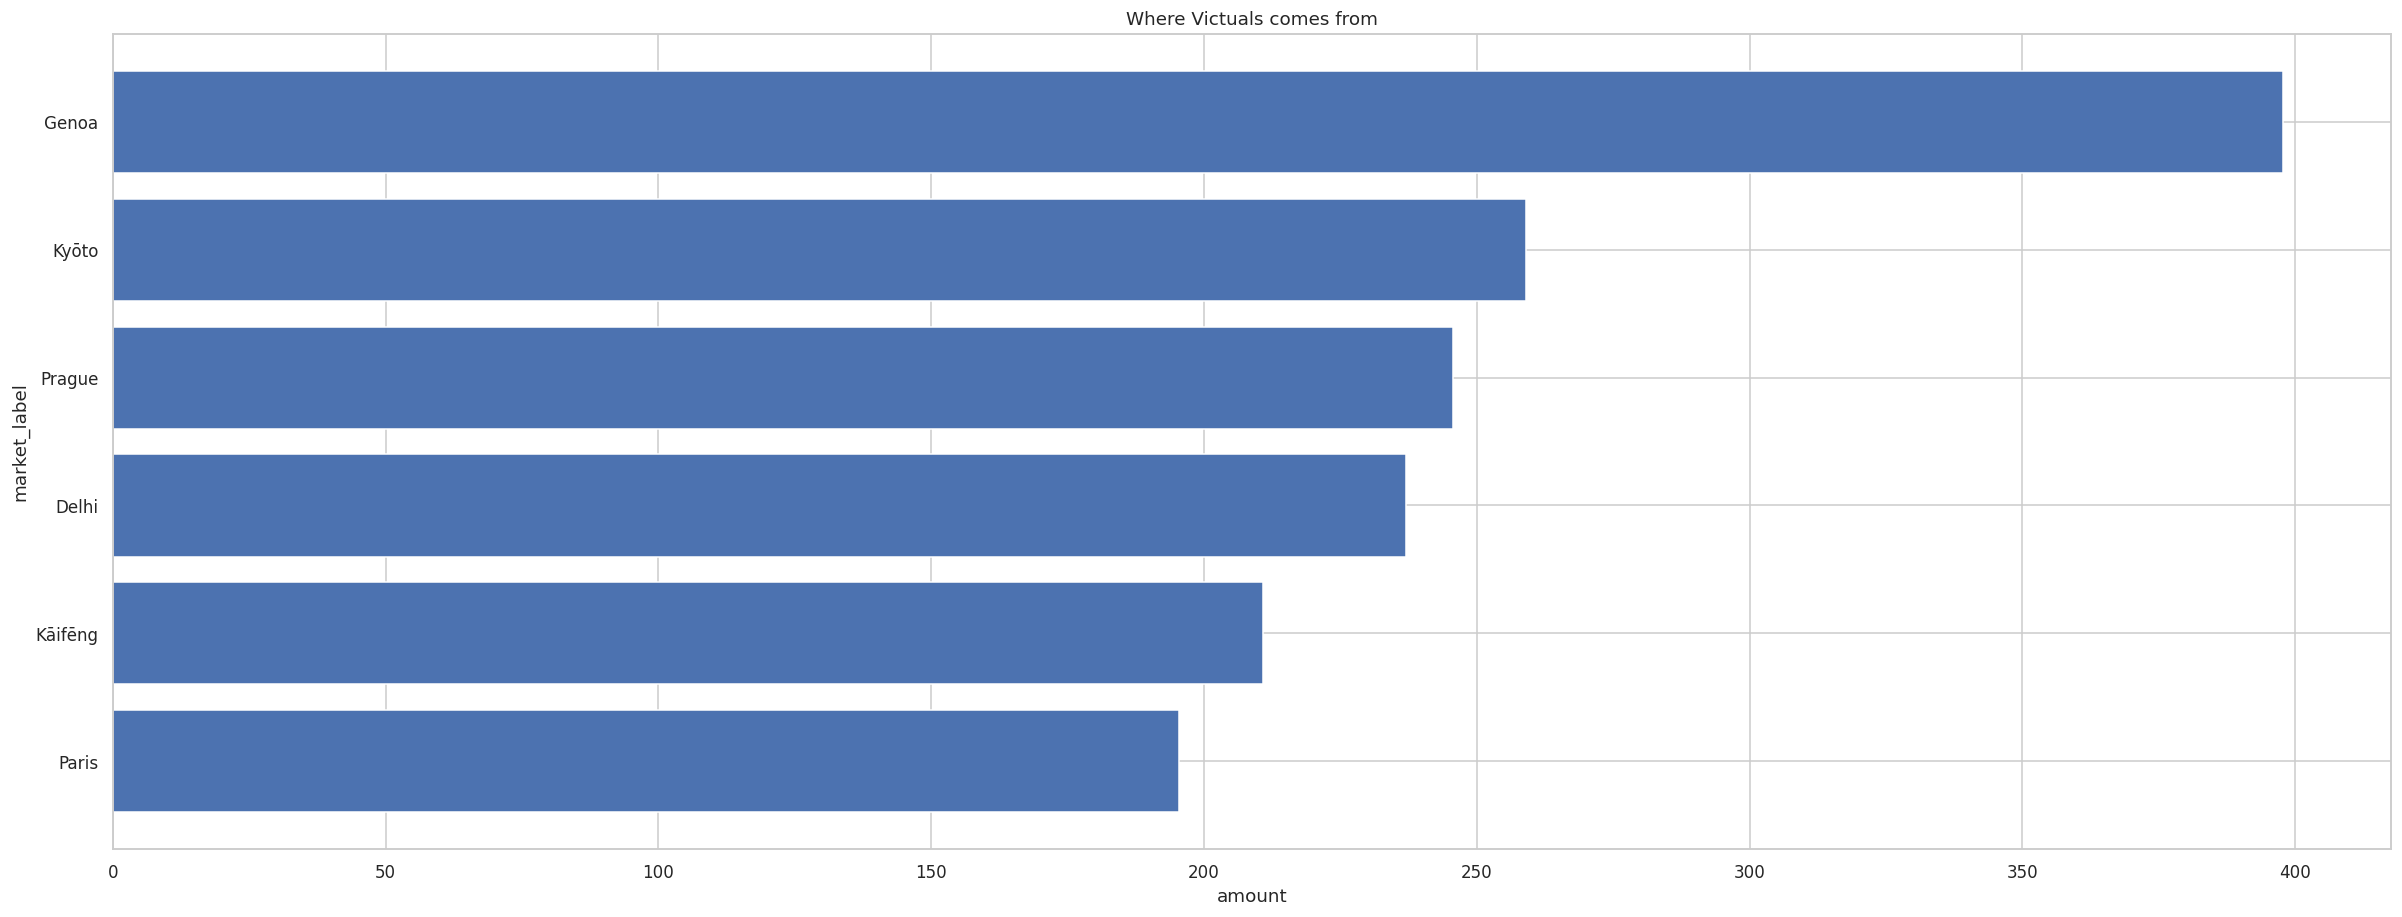

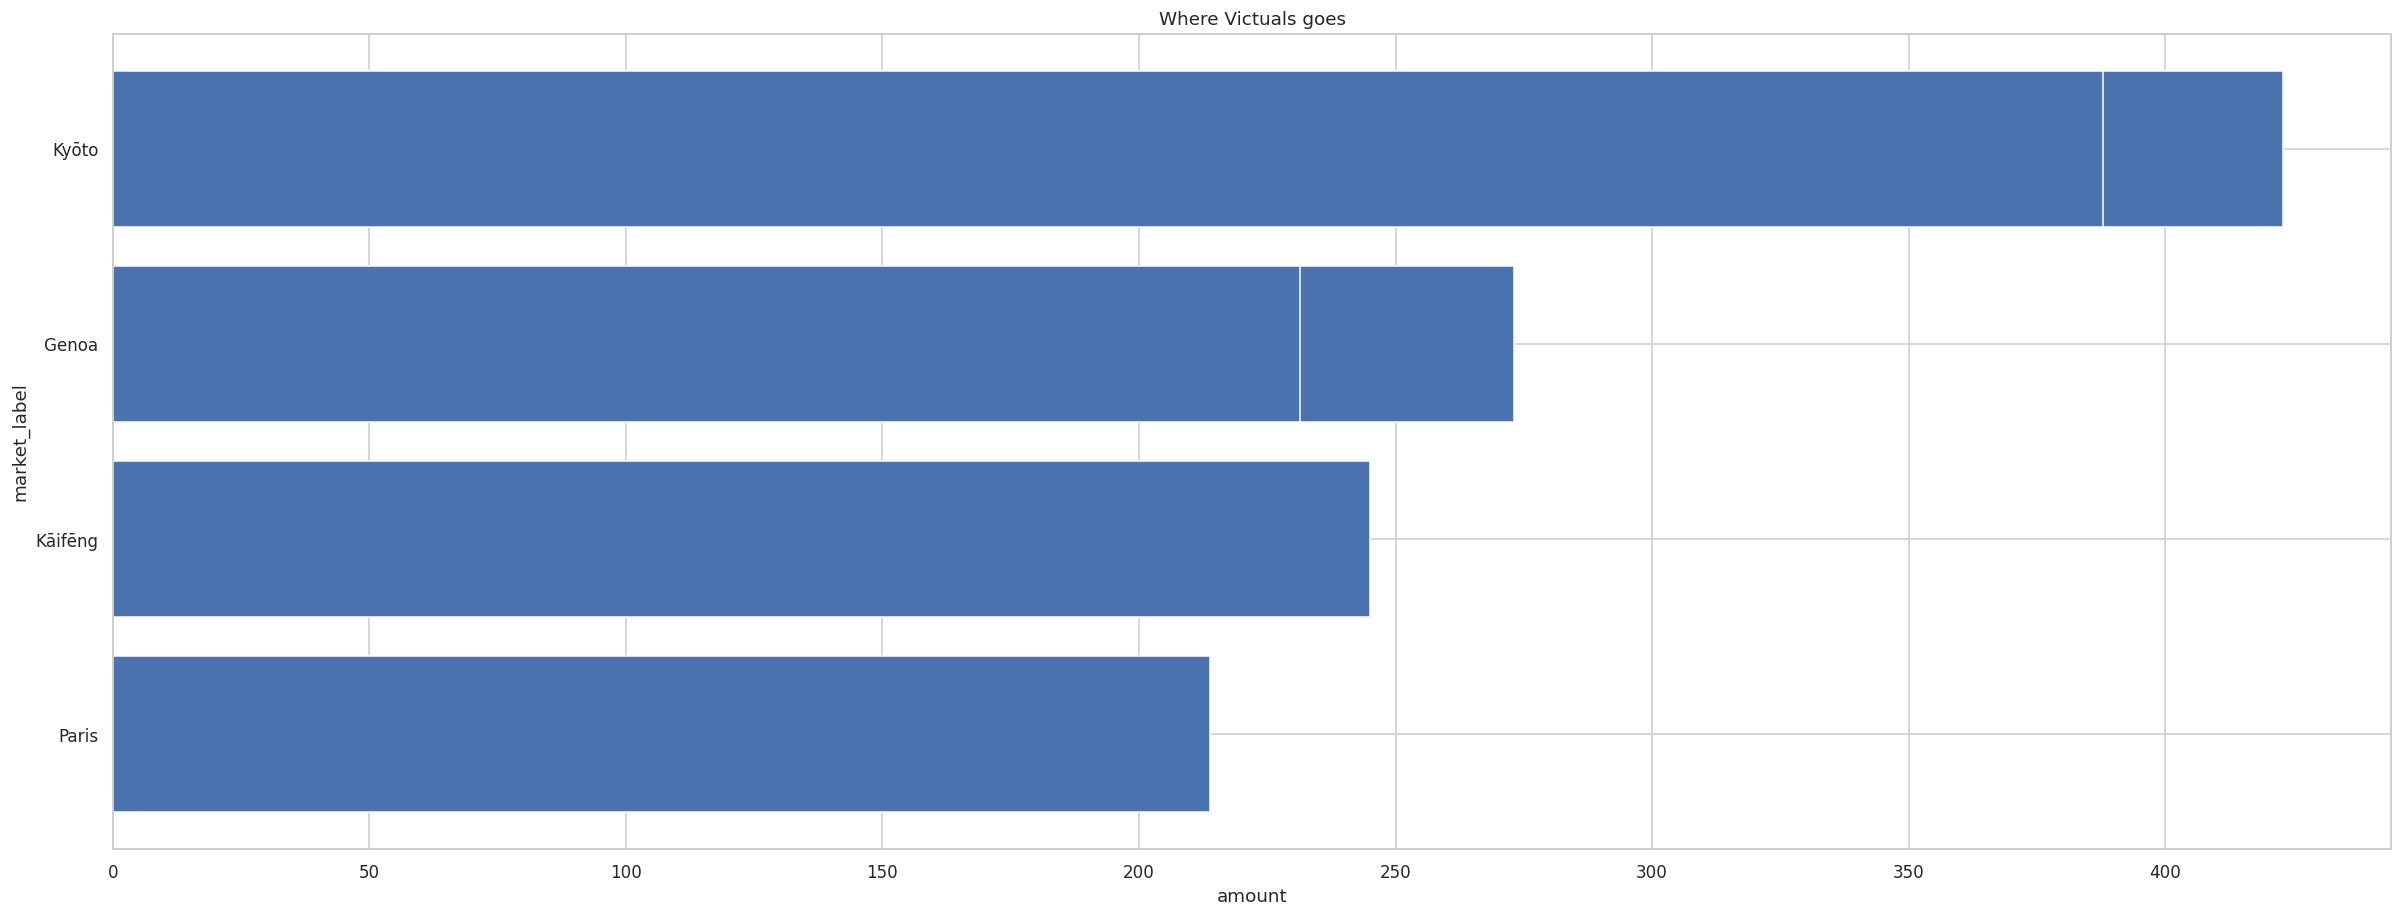

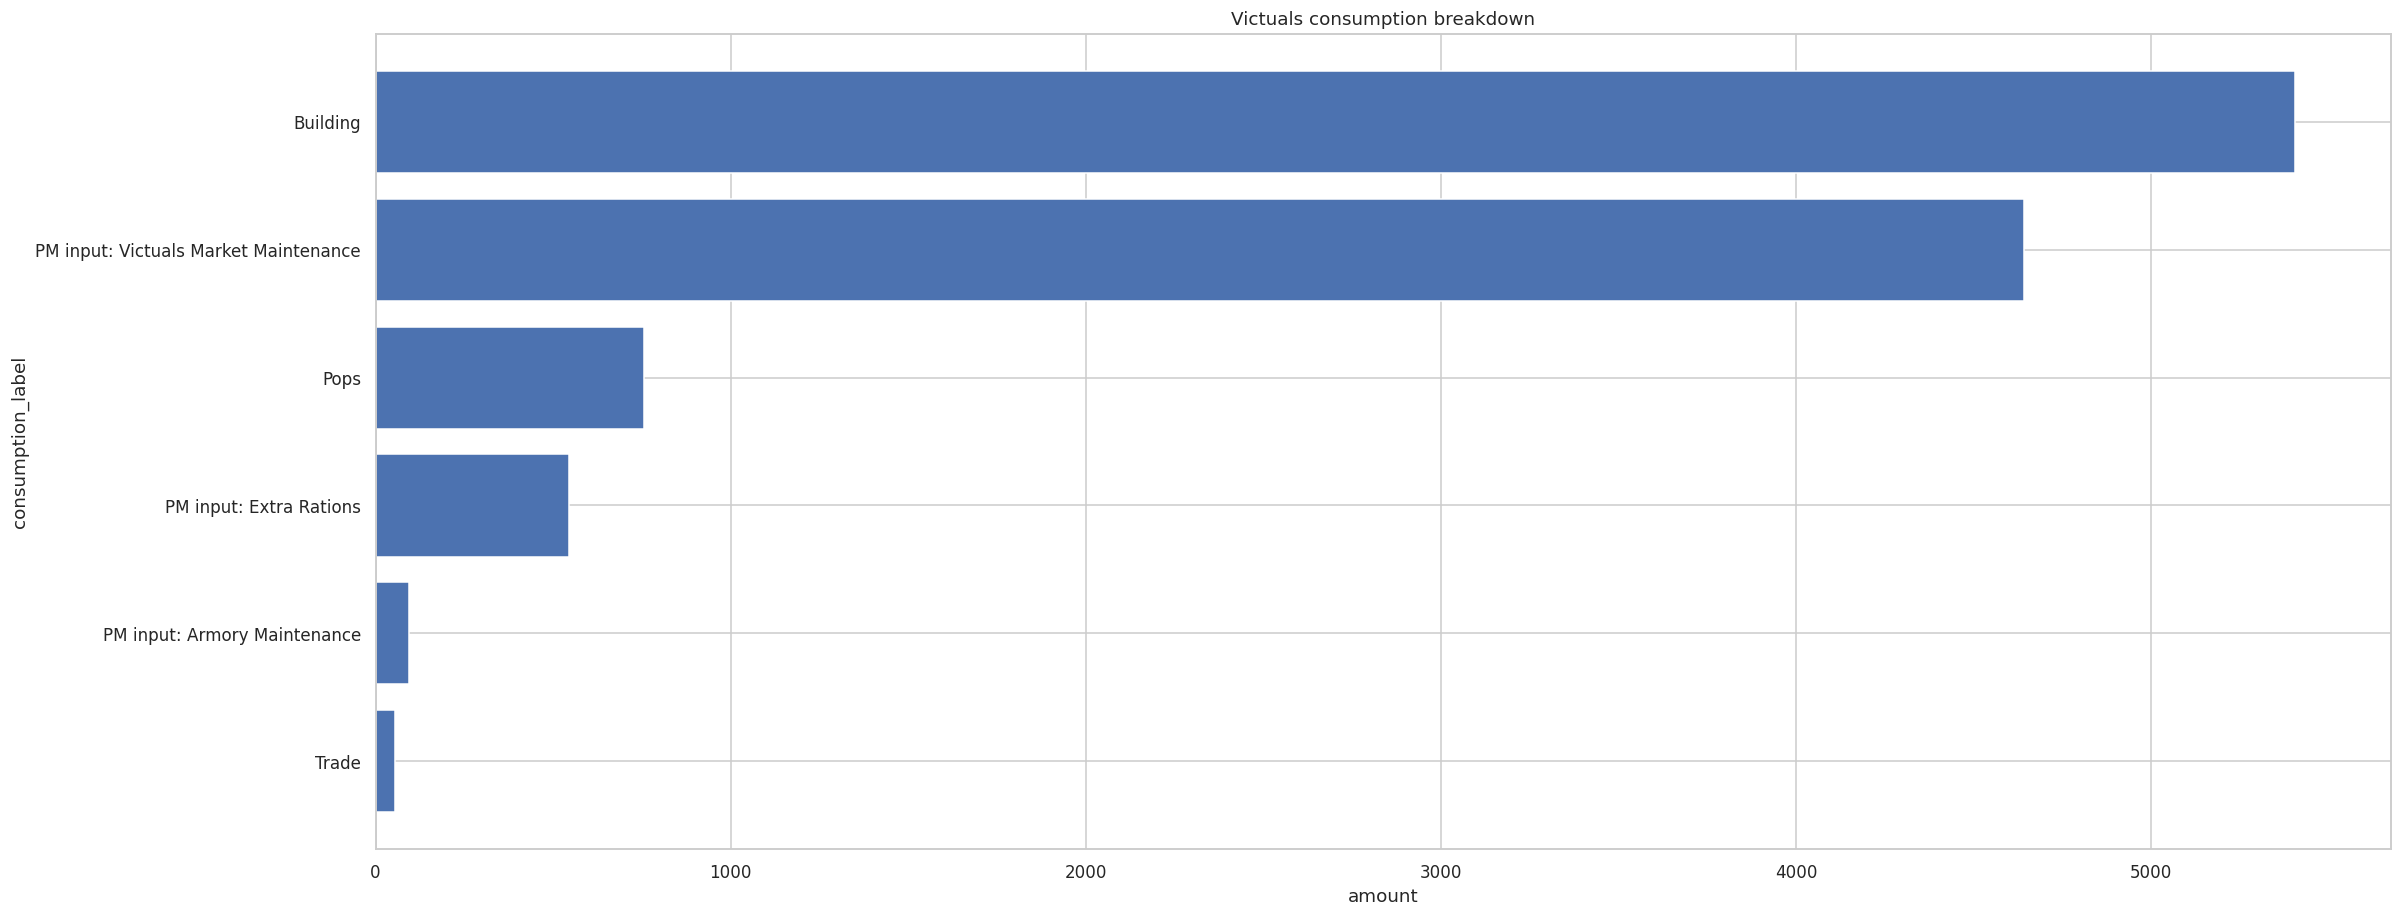

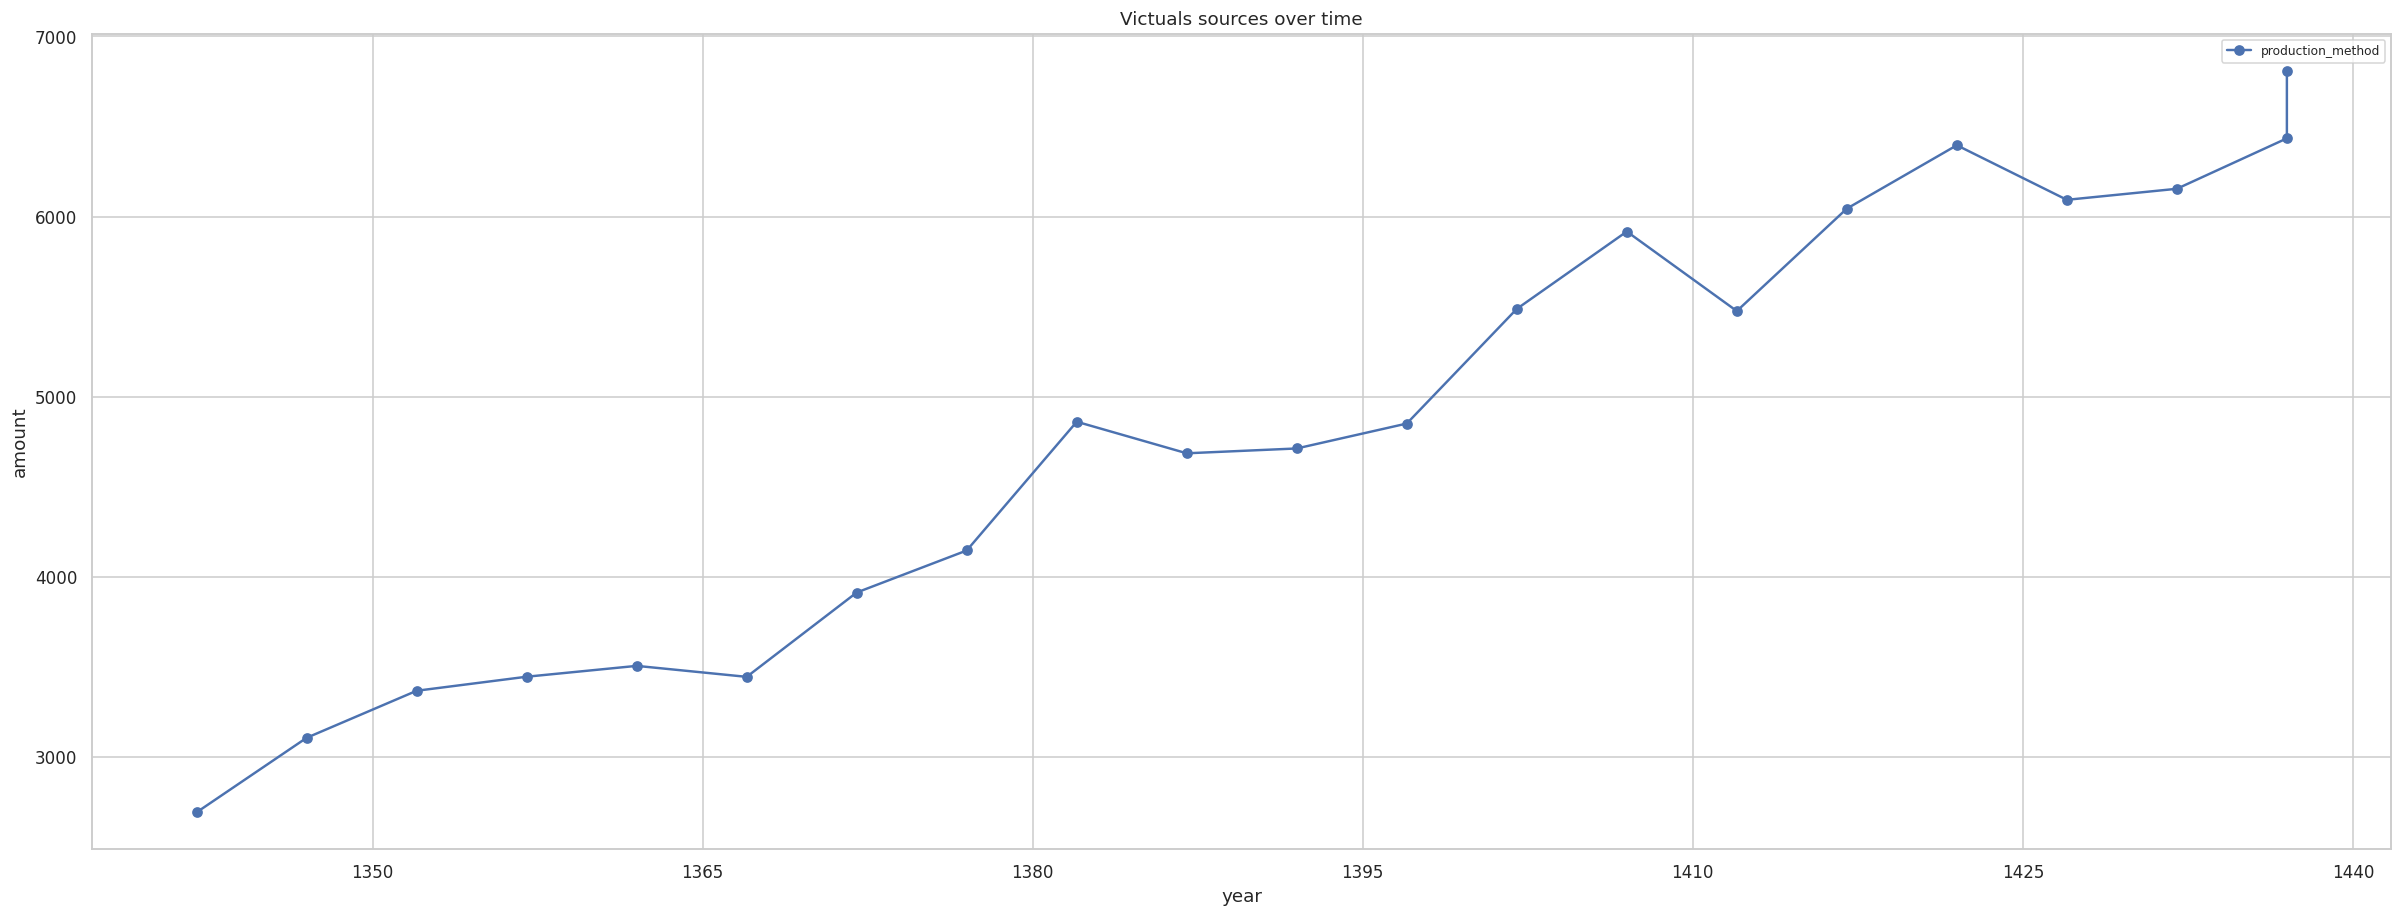

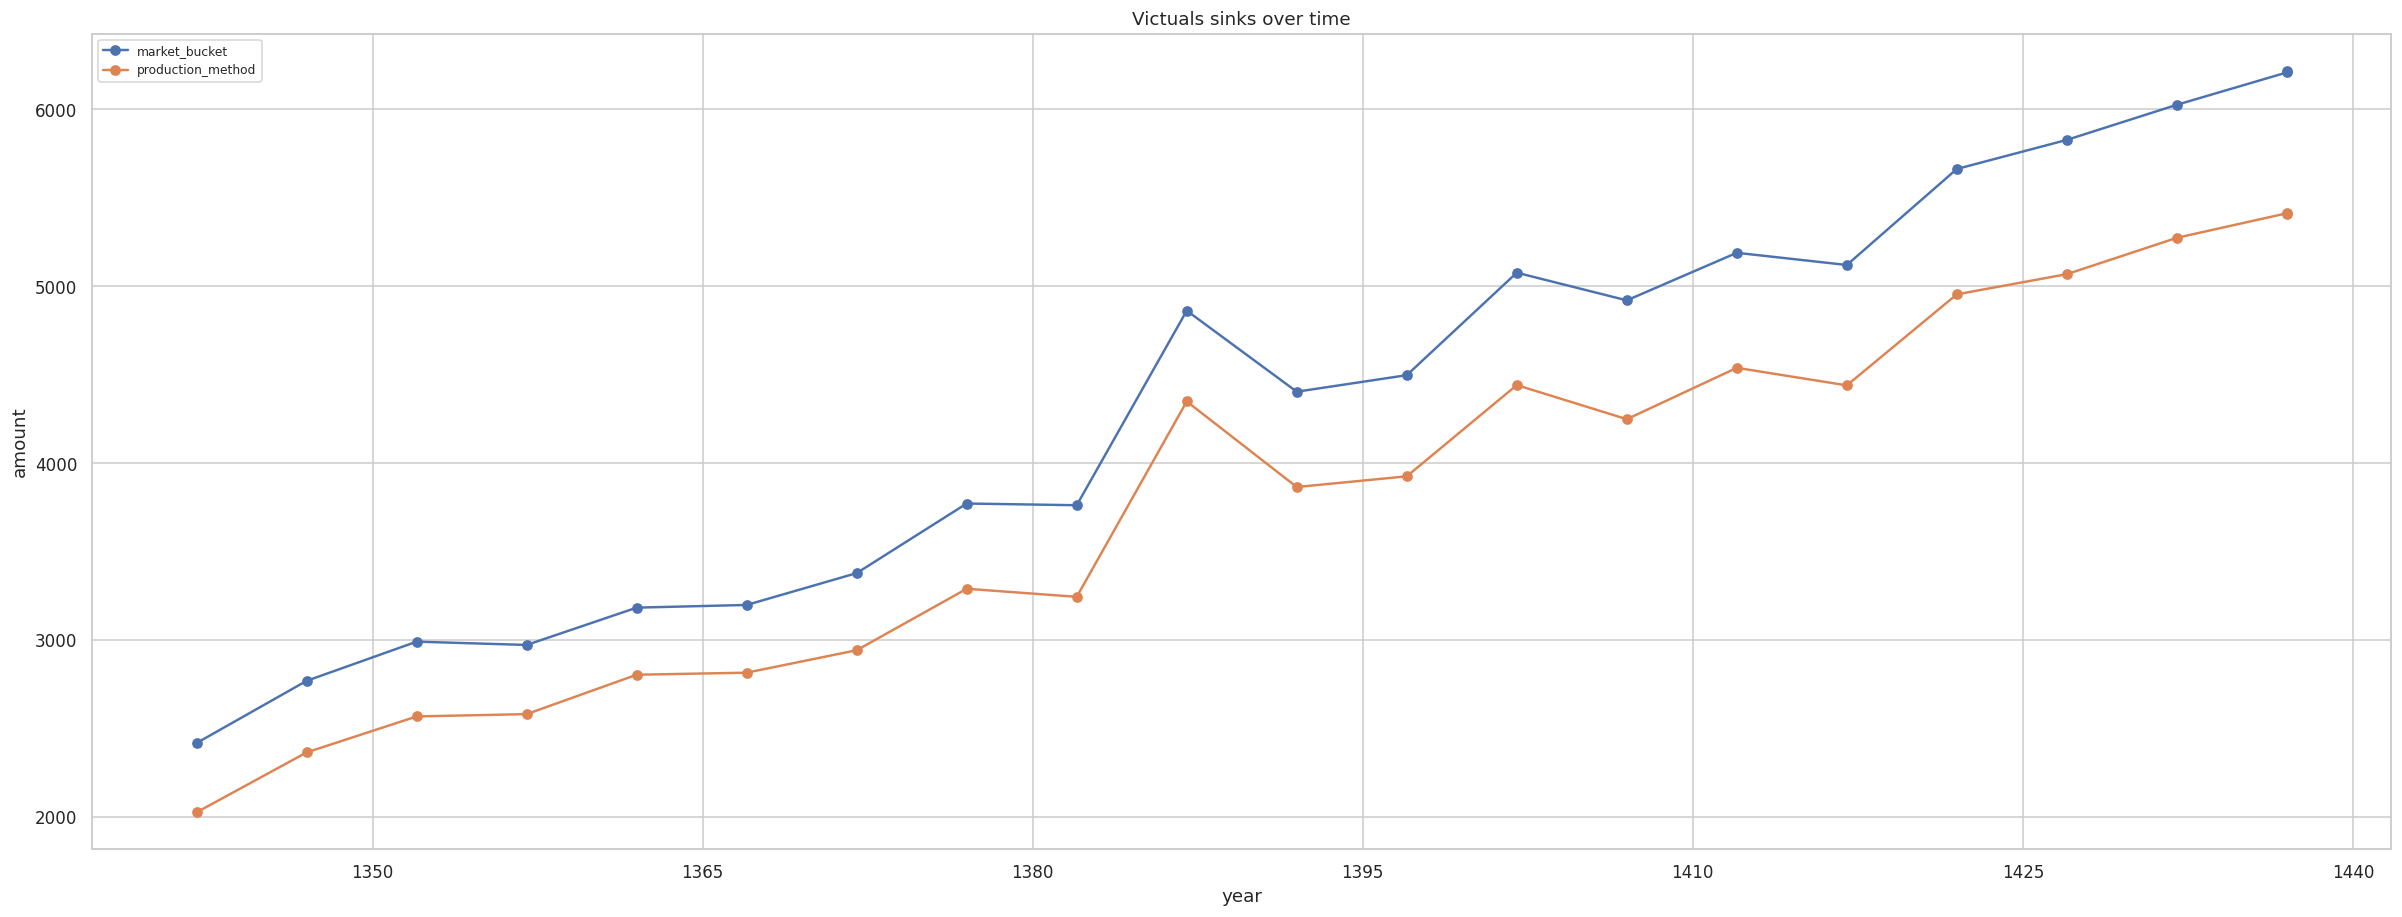

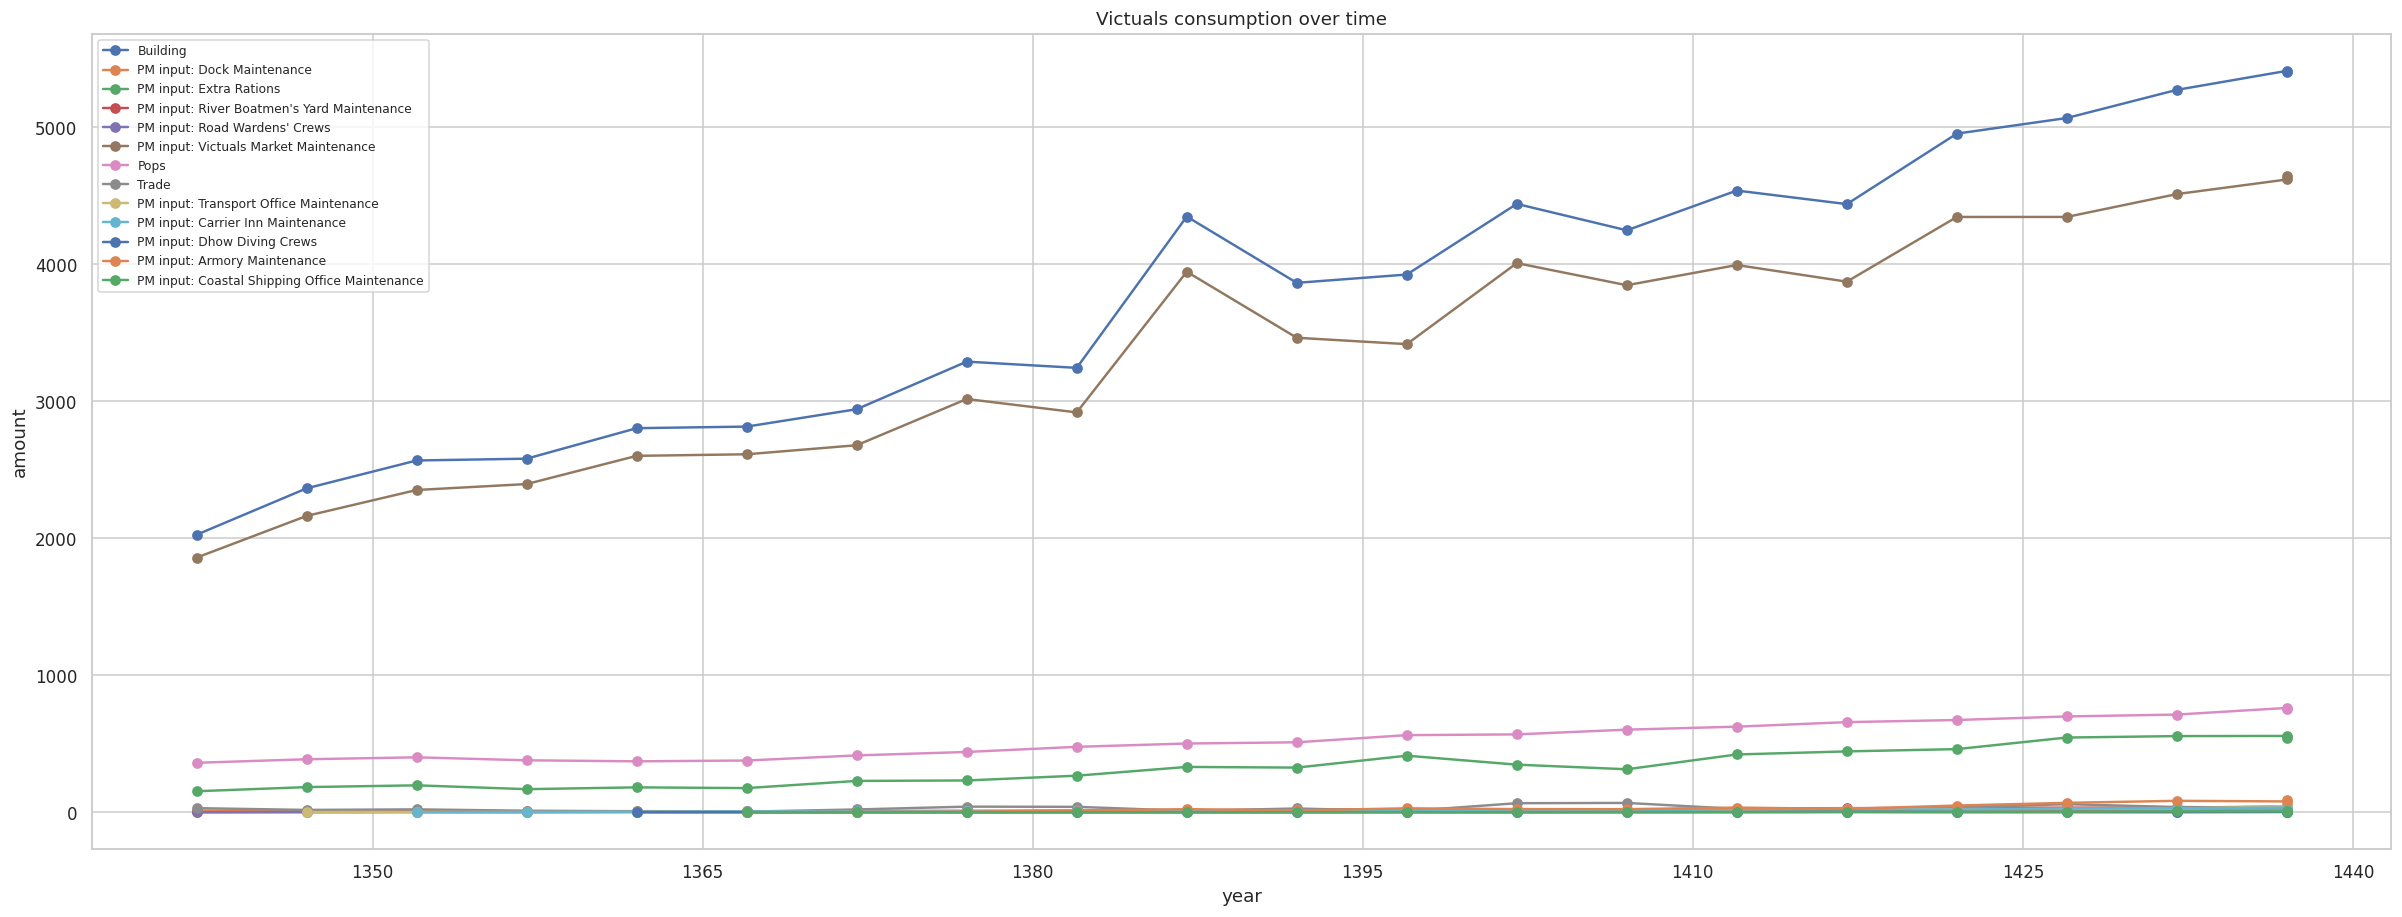

In [13]:
workbench.plot_flows(flows)


## Food Markets

In [14]:
# Uses food_rank_by/market_search from the main selection cell.
food = workbench.food()
food_rank = food.rank
food_global = food.global_time_series
food_price_distribution = food.price_distribution
food_delta = food.delta


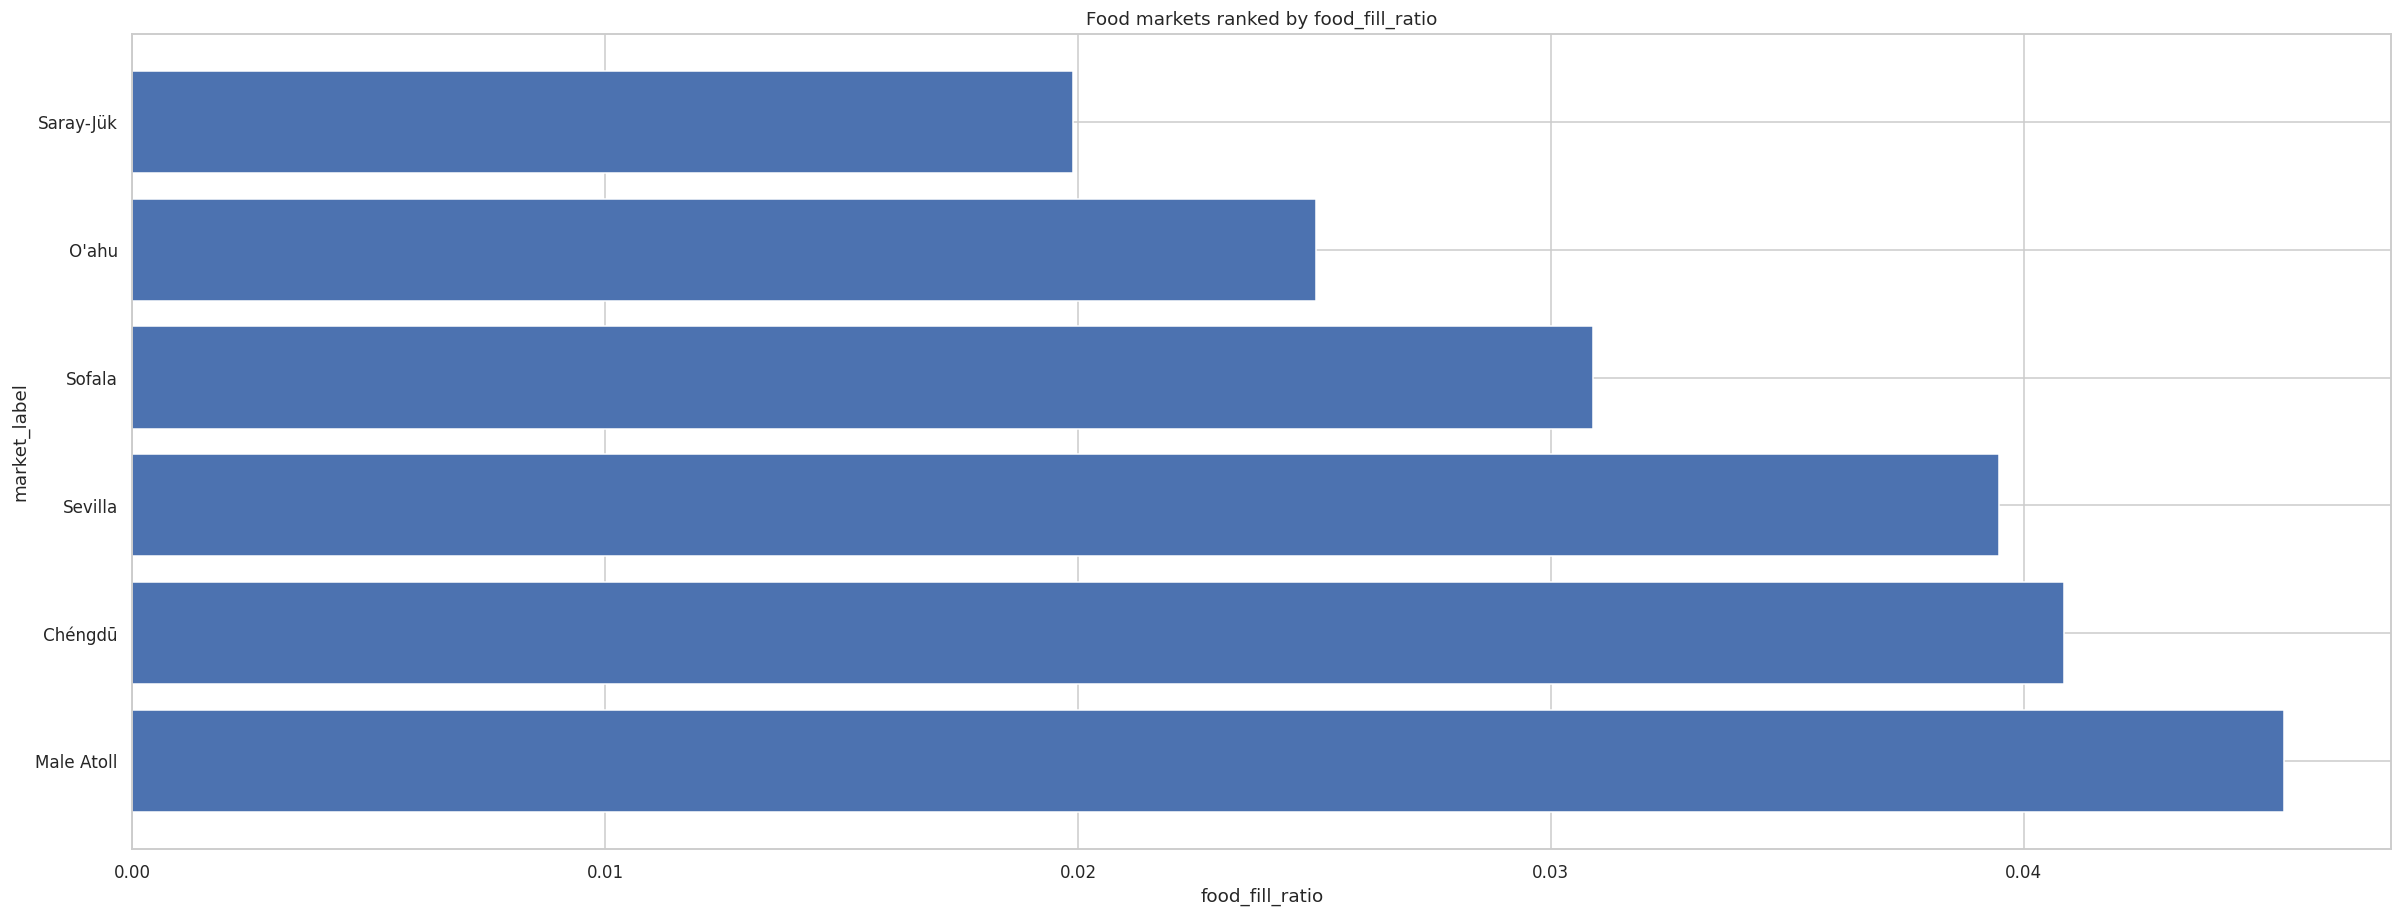

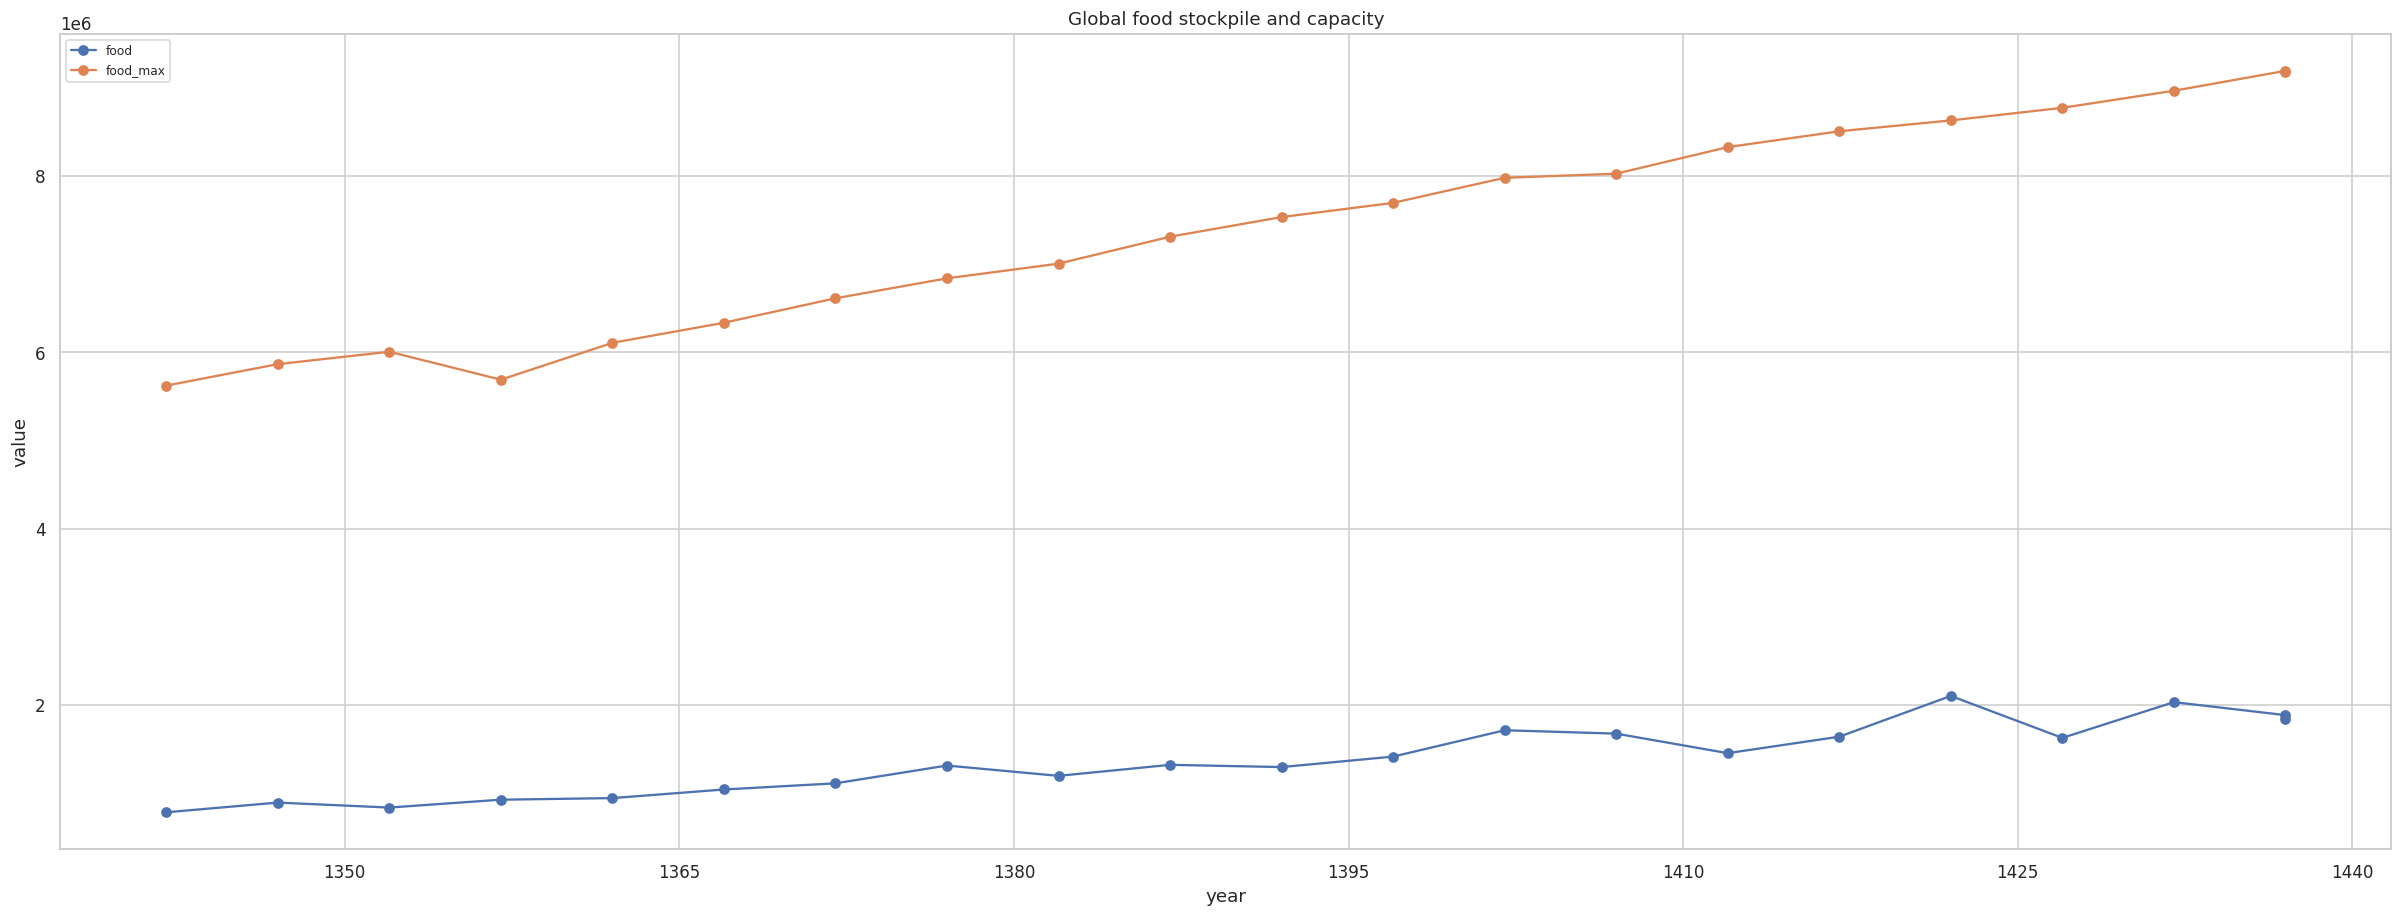

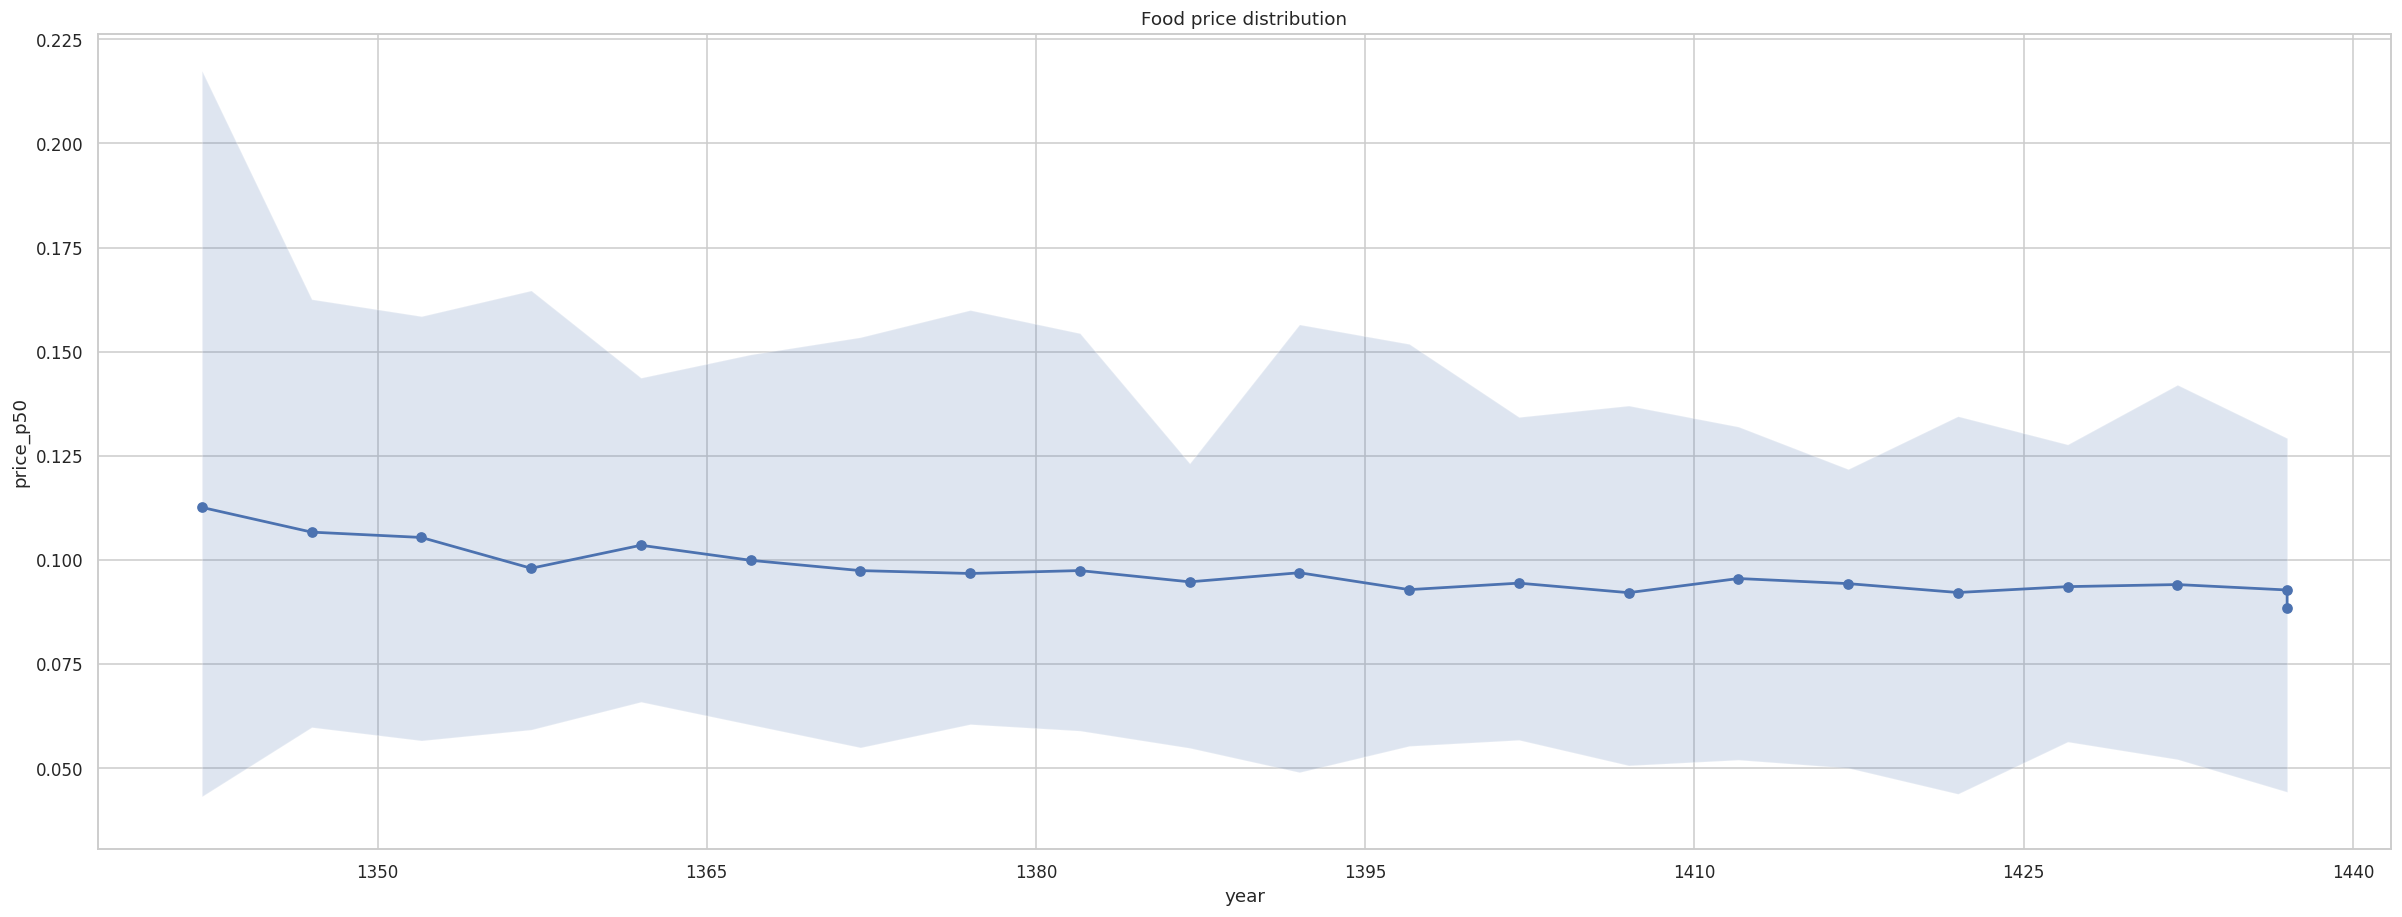

In [15]:
workbench.plot_food(food)


In [ ]:
# Uses playthrough/start/end/market_search from the main selection cell.
food_price_volatility = nb.show_food_price_volatility(data, workbench, top_n=12)
food_price_stats = food_price_volatility.stats
erratic_food_markets = food_price_volatility.top_erratic


In [ ]:
map_data = nb.open_data(playthrough=playthrough, tables=("locations", "market_food"), load_map_assets=True)
food_price_map = nb.show_food_price_map(
    map_data,
    scope="super_region",
    name=None,
    width=1600,
    playthrough=playthrough,
    start_date=start_date,
    end_date=end_date,
)


## Buildings And Production Methods

In [16]:
# Uses building_search/building_scope/building_metric from the main selection cell.
buildings = workbench.buildings()
building_latest = buildings.latest
building_ts = buildings.time_series
pm_adoption = buildings.pm_adoption
pm_preferences = buildings.pm_preferences
pm_regional_preferences_by_slot = buildings.pm_regional_preferences_by_slot
pm_slot_ts = buildings.pm_slot_time_series
pm_usage_by_slot_over_time = buildings.pm_usage_by_slot_over_time
pm_values = buildings.pm_values


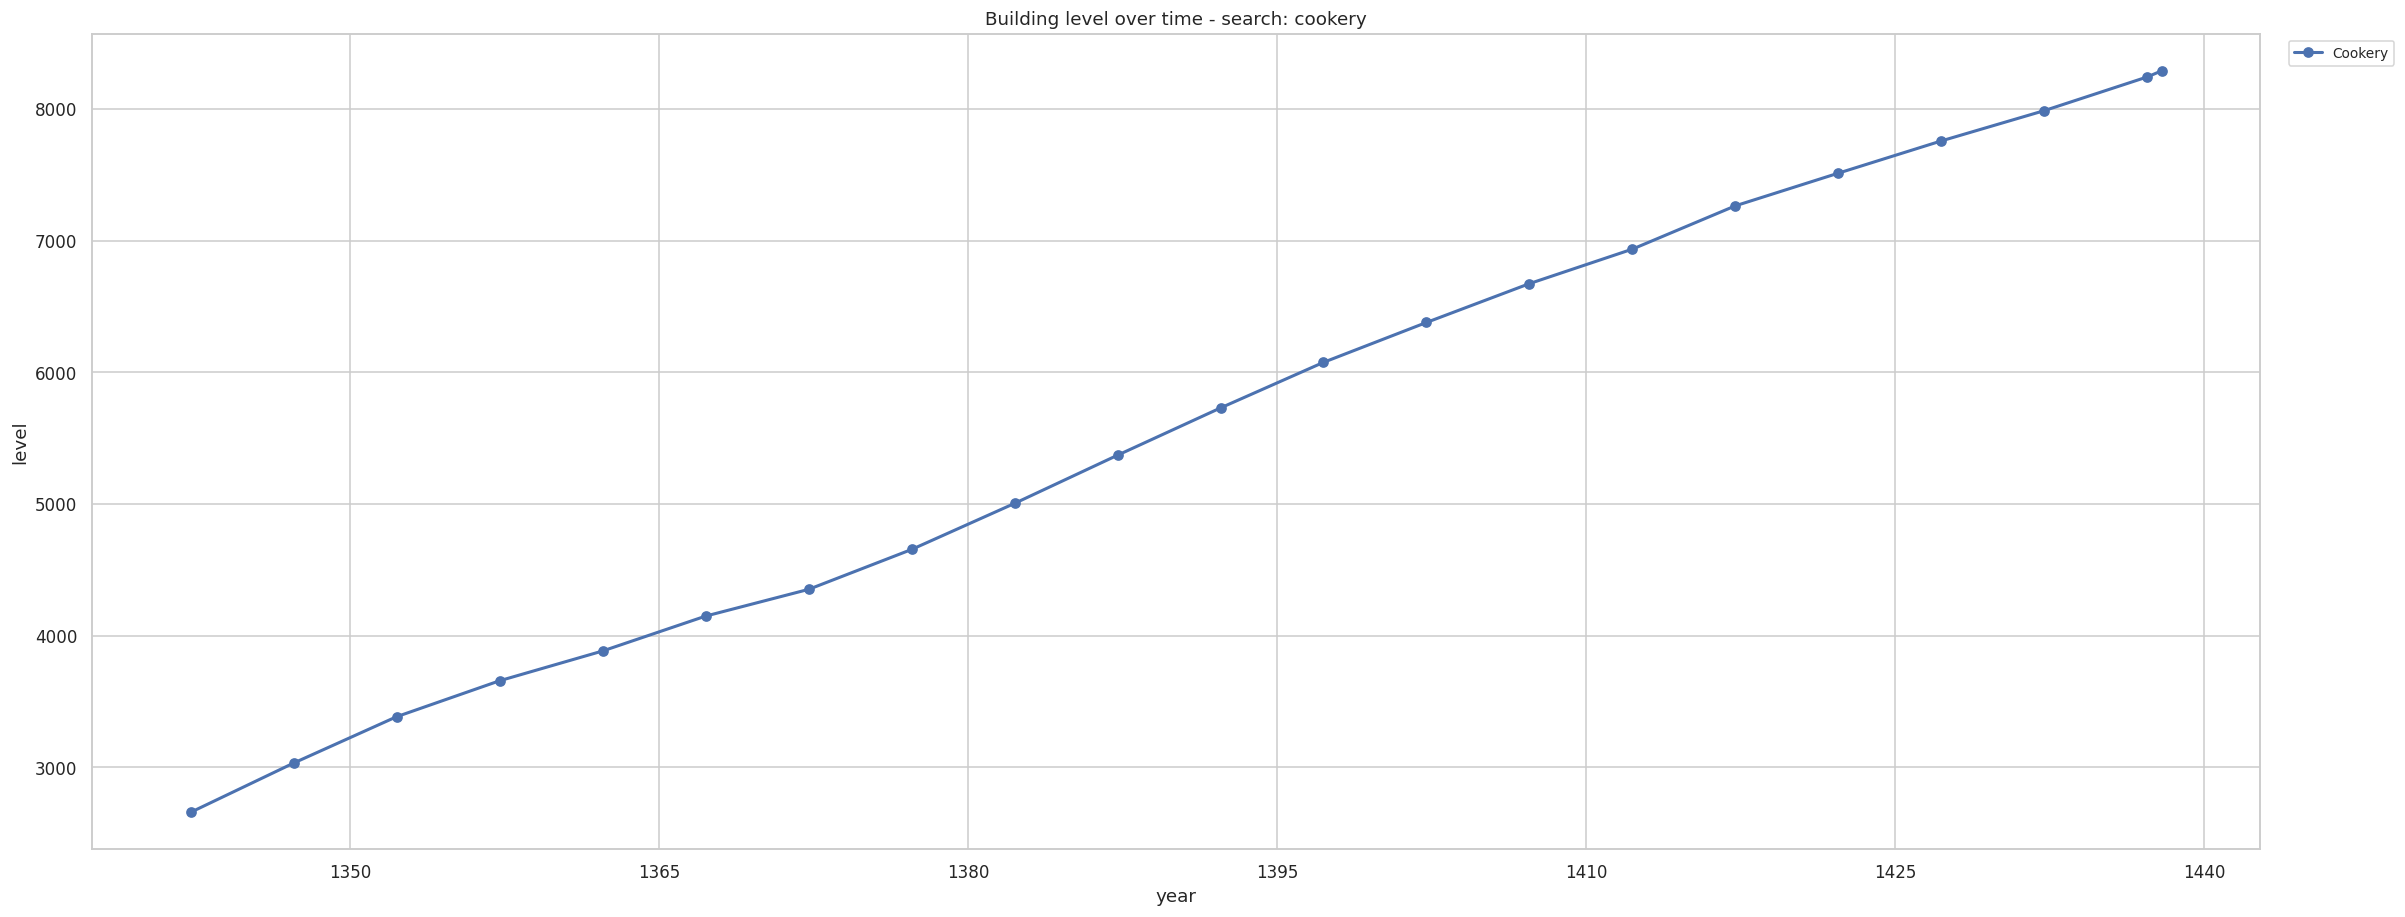

In [17]:
# Examples:
# tag_filter = None                 # e.g. "farming_capacity"; intersects with building_search
# metric = None                     # None uses building_metric from the main selection cell
# top_n = None                      # None uses top_n from the main selection cell
tag_filter = None
metric = None
top_n_override = None

building_absolute = nb.show_building_absolute_time_series(
    data,
    workbench,
    tag_filter=tag_filter,
    metric=metric,
    top_n=top_n_override,
)
building_absolute_ts = building_absolute.time_series
building_absolute_ts_top = building_absolute.top_time_series
building_tag_matches = building_absolute.tag_matches
building_tag_options = building_absolute.tag_options
building_absolute_metric = building_absolute.metric


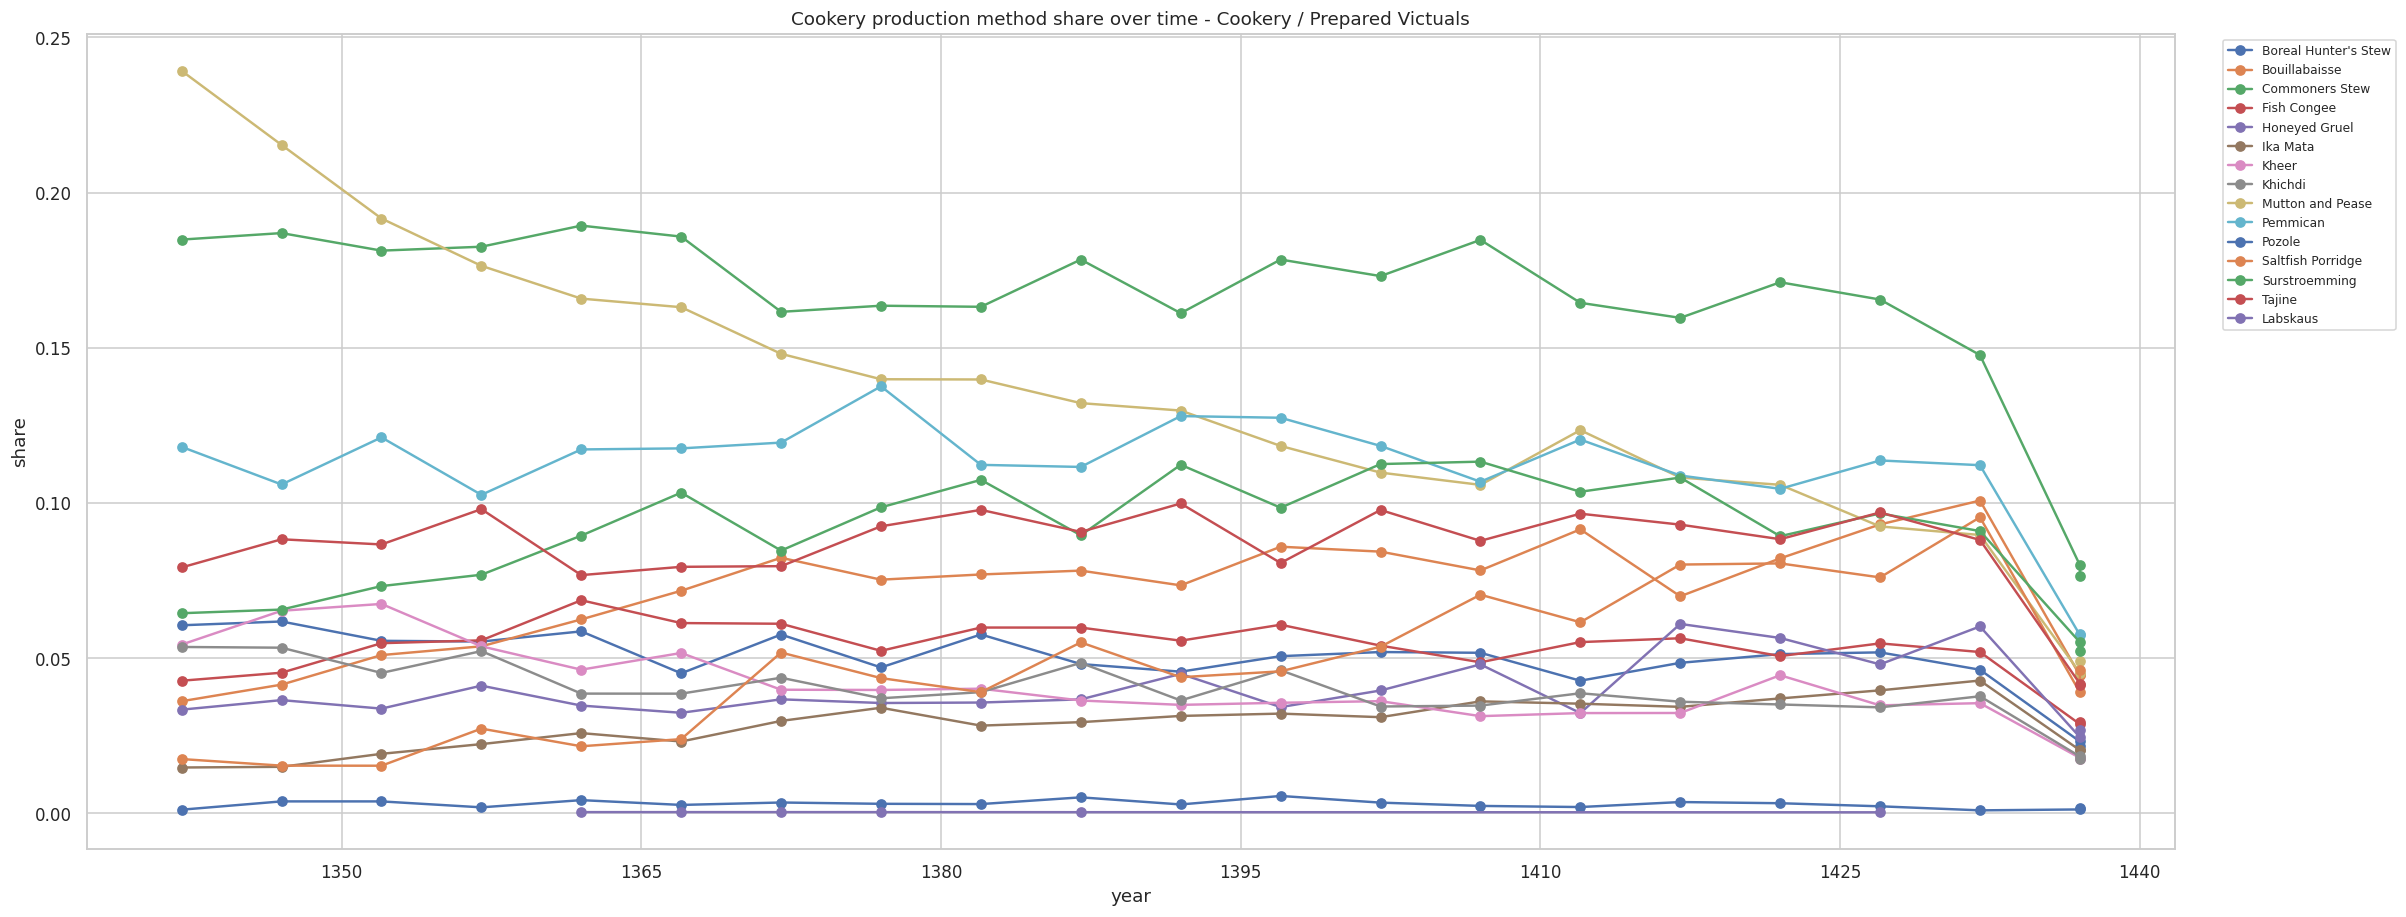

In [18]:
# Examples:
# slot_index = 0
slot_index = 0
nb.show_building_slot(workbench, buildings, slot=slot_index)


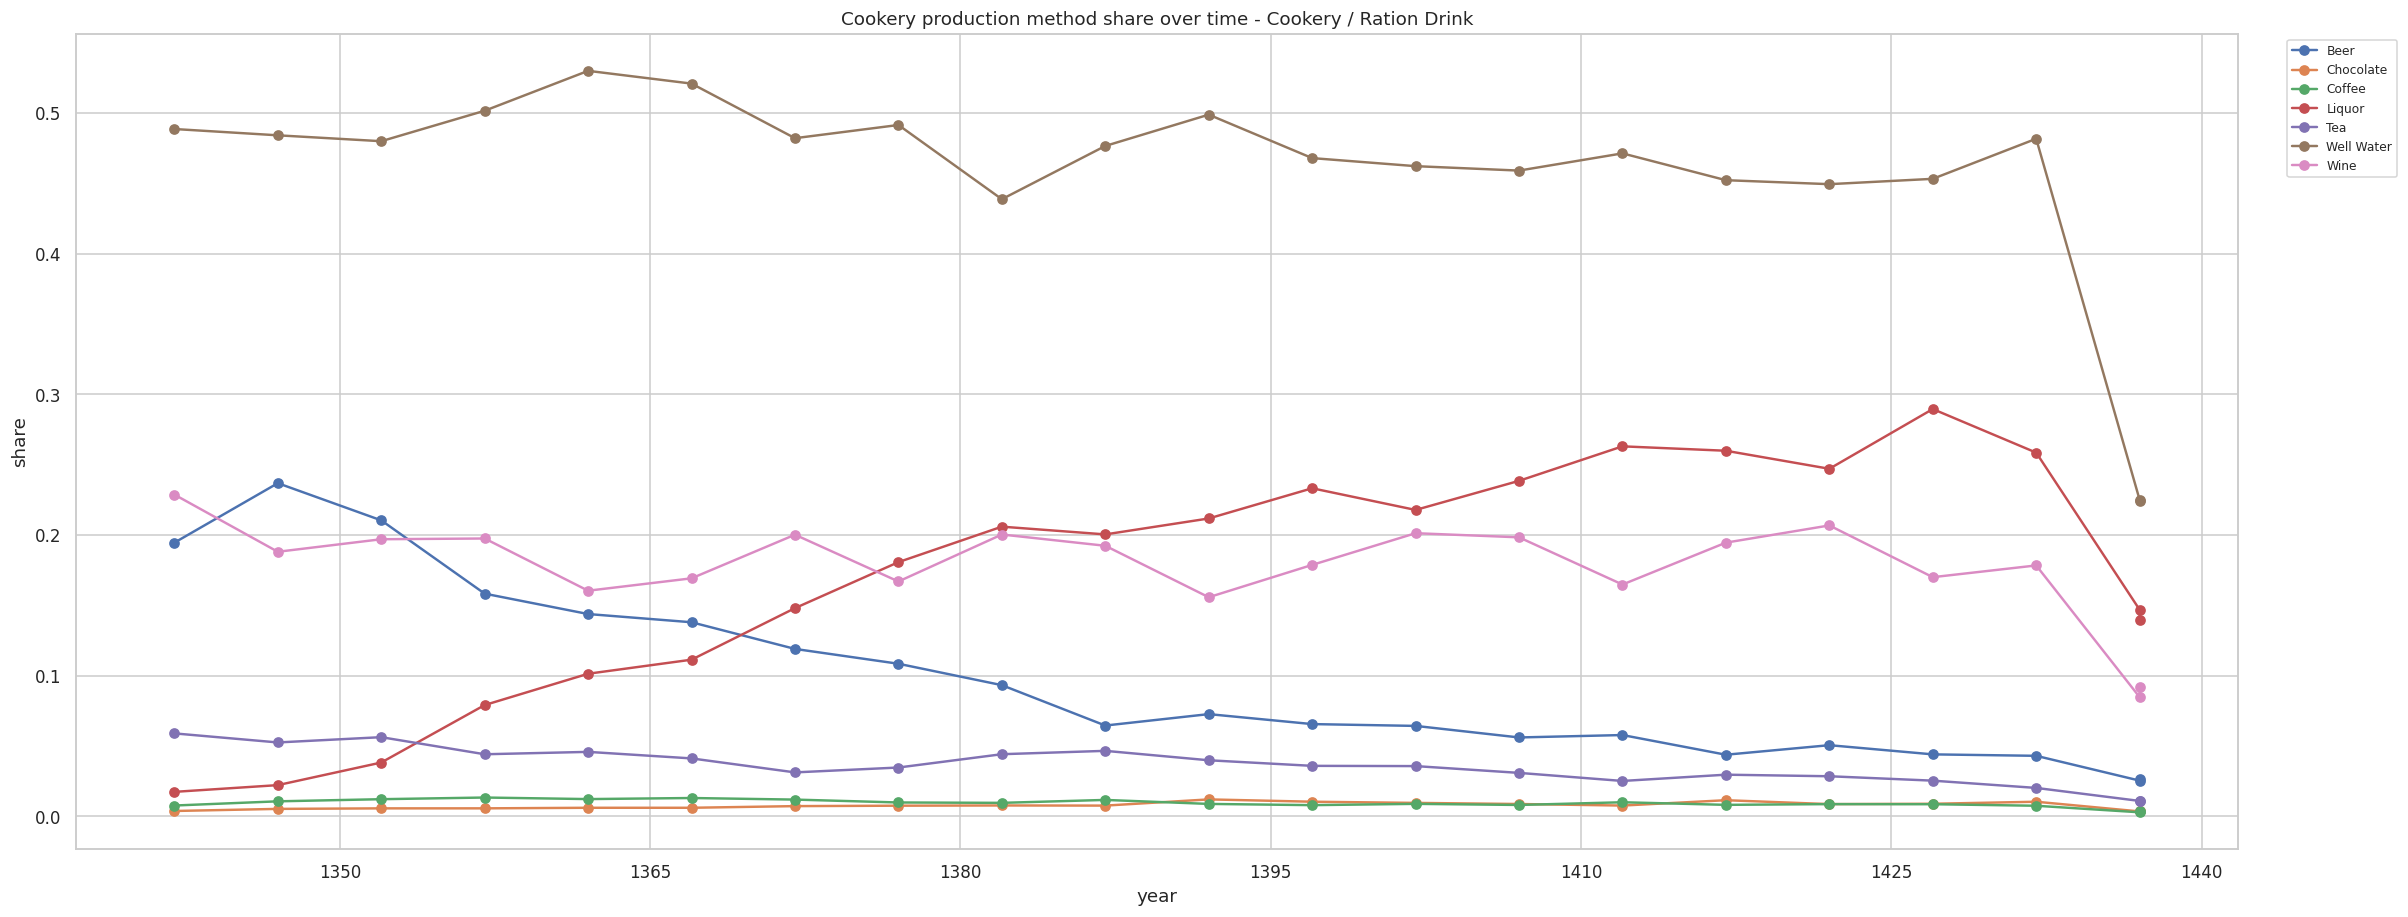

In [19]:
# Examples:
# slot_index = 1
slot_index = 1
nb.show_building_slot(workbench, buildings, slot=slot_index)


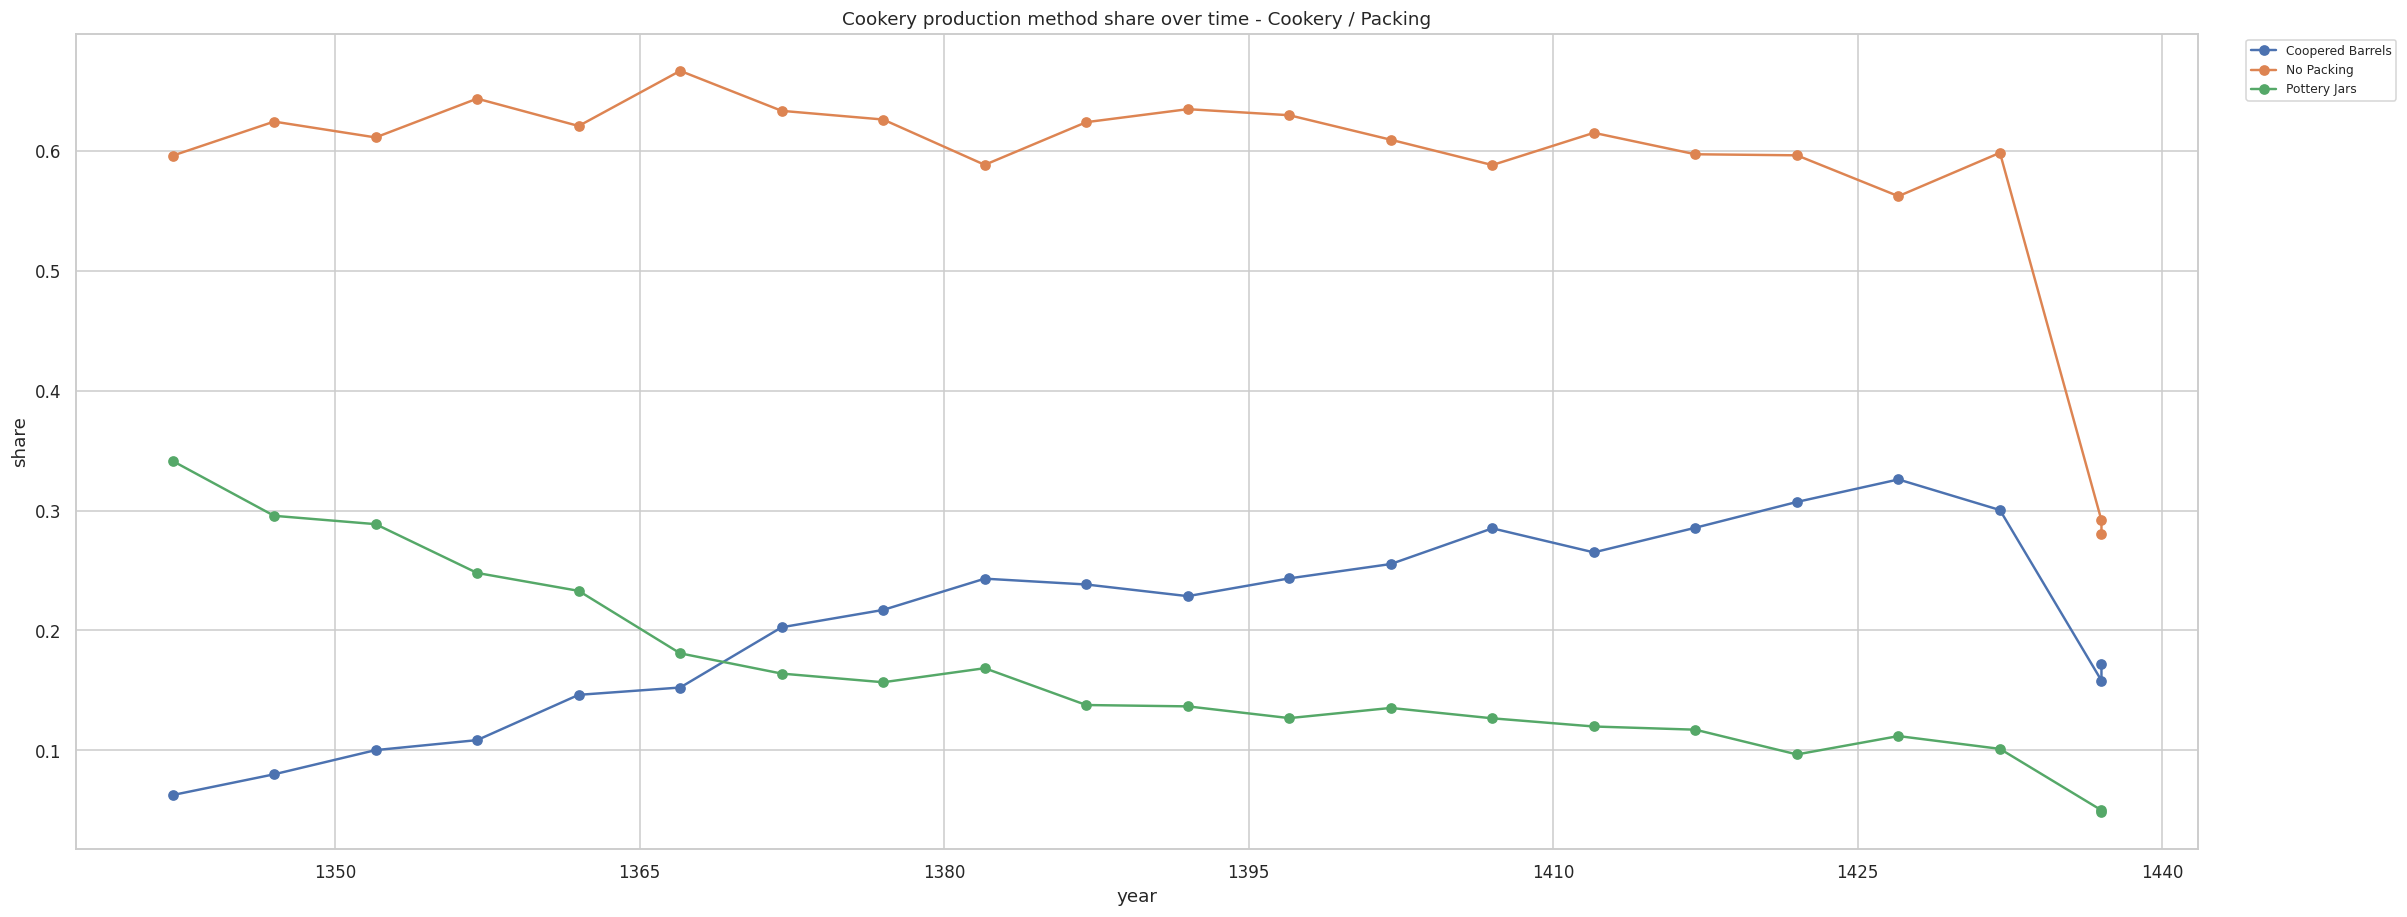

In [20]:
# Examples:
# slot_index = 2
slot_index = 2
nb.show_building_slot(workbench, buildings, slot=slot_index)
